In [52]:
import warnings                                  # `do not disturbe` mode
warnings.filterwarnings('ignore')

import numpy as np                               # vectors and matrices
import pandas as pd                              # tables and data manipulations
import matplotlib.pyplot as plt                  # plots
import seaborn as sns                            # more plots

from dateutil.relativedelta import relativedelta # working with dates with style
from scipy.optimize import minimize              # for function minimization

import statsmodels.formula.api as smf            # statistics and econometrics
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs

from itertools import product                    # some useful functions
from tqdm import tqdm_notebook



%matplotlib inline

# Introduction

We begin with a simple [definition](https://en.wikipedia.org/wiki/Time_series) of time series:
> *Time series* is a series of data points indexed (or listed or graphed) in time order.

Therefore, the data is organized by relatively deterministic timestamps, and may, compared to random sample data, contain additional information that we can extract.

Let's import some libraries. First, we will need the [statsmodels](http://statsmodels.sourceforge.net/stable/) library, which has many statistical modeling functions, including time series. For R afficionados who had to move to Python, `statsmodels` will definitely look more familiar since it supports model definitions like 'Wage ~ Age + Education'.

## Forecast quality metrics

Before we begin forecasting, let's understand how to measure the quality of our predictions and take a look at the most commonly used metrics.

- [R squared](http://scikit-learn.org/stable/modules/model_evaluation.html#r2-score-the-coefficient-of-determination): coefficient of determination (in econometrics, this can be interpreted as the percentage of variance explained by the model), $(-\infty, 1]$

$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$ 

```python
sklearn.metrics.r2_score
```
---
- [Mean Absolute Error](http://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-error): this is an interpretable metric because it has the same unit of measurment as the initial series, $[0, +\infty)$

$MAE = \frac{\sum\limits_{i=1}^{n} |y_i - \hat{y}_i|}{n}$ 

```python
sklearn.metrics.mean_absolute_error
```
---
- [Median Absolute Error](http://scikit-learn.org/stable/modules/model_evaluation.html#median-absolute-error): again, an interpretable metric that is particularly interesting because it is robust to outliers, $[0, +\infty)$

$MedAE = median(|y_1 - \hat{y}_1|, ... , |y_n - \hat{y}_n|)$

```python
sklearn.metrics.median_absolute_error
```
---
- [Mean Squared Error](http://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error): the most commonly used metric that gives a higher penalty to large errors and vice versa, $[0, +\infty)$

$MSE = \frac{1}{n}\sum\limits_{i=1}^{n} (y_i - \hat{y}_i)^2$

```python
sklearn.metrics.mean_squared_error
```
---
- [Mean Squared Logarithmic Error](http://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-logarithmic-error): practically, this is the same as MSE, but we take the logarithm of the series. As a result, we give more weight to small mistakes as well. This is usually used when the data has exponential trends, $[0, +\infty)$

$MSLE = \frac{1}{n}\sum\limits_{i=1}^{n} (log(1+y_i) - log(1+\hat{y}_i))^2$

```python
sklearn.metrics.mean_squared_log_error
```
---
- Mean Absolute Percentage Error: this is the same as MAE but is computed as a percentage, which is very convenient when you want to explain the quality of the model to management, $[0, +\infty)$

$MAPE = \frac{100}{n}\sum\limits_{i=1}^{n} \frac{|y_i - \hat{y}_i|}{y_i}$ 

```python
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
```

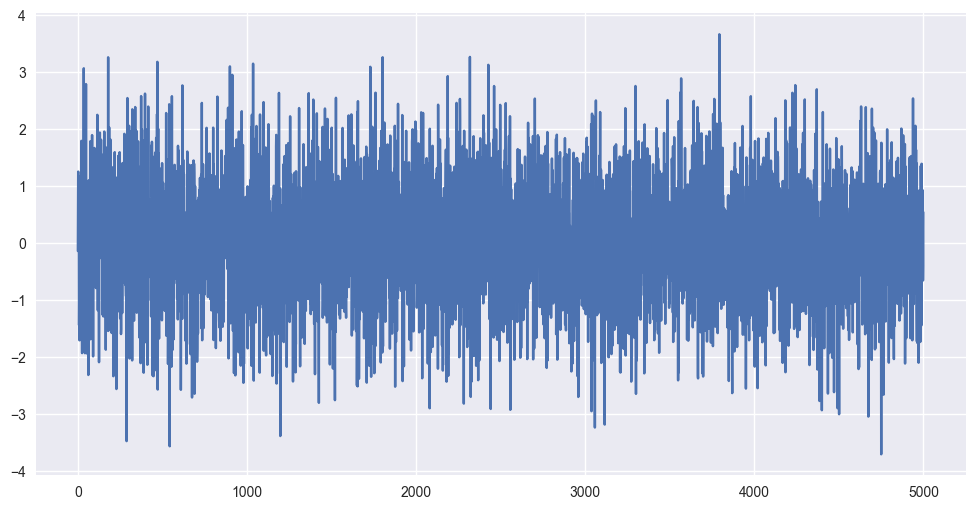

In [ ]:
### demo with the simplest time series we can have

noise = np.random.normal(loc=0, scale=1, size=5000)
plt.plot(noise)
plt.show()

## y= f(X) + epsilon : epsilon = white noise

In [ ]:
### X1, X2 features

## cov(X1,x2) = E(X1 - EX1)(X2 - EX2) ## bidimensional measure of dispersion of the rvs X1, X2 together from their mean

## corr(X1,X2) := cov(X1, X2)/(std(X1) std(X2)) in (0,1)
## var(X1)= E(X1 - (EX1)^2) ### dispersion of the random variable X1 from the mean value X1


## X=(X_t)= (X1, X2, X3, ..., Xt, X_{t+1})

## autocorrelations of the time series

## AUto correlation 1 periods corr(X_t,X_{t+1})

In [54]:
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

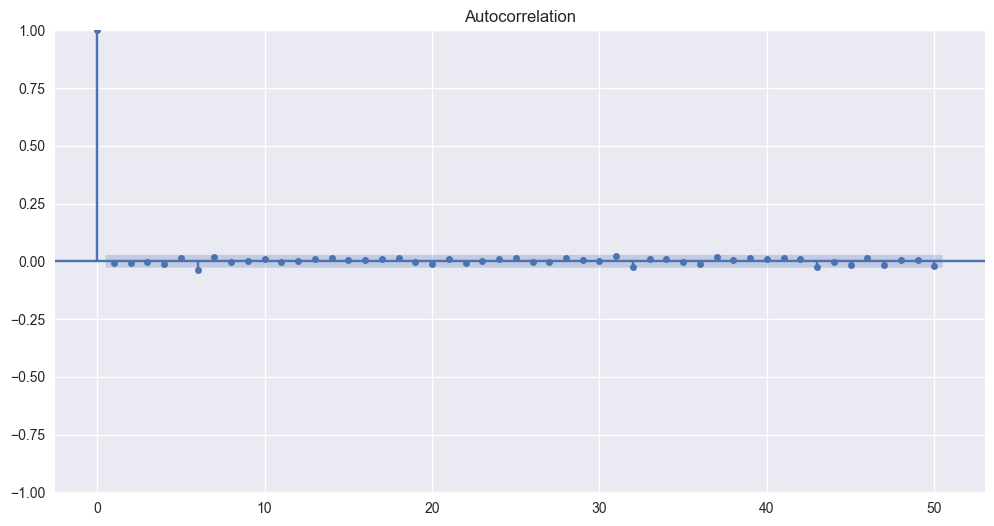

In [55]:
plot_acf(noise, lags=50)
plt.show()

In [56]:
## stationarity of the time series can be seen by the autocorrelation plot: if it looks like the one before you have a stationary time series

#### random walk

\begin{align}
P_{t} = P_{t-1} + w_t = P_0 + \sum_{k=1}^t w_k 
\end{align}

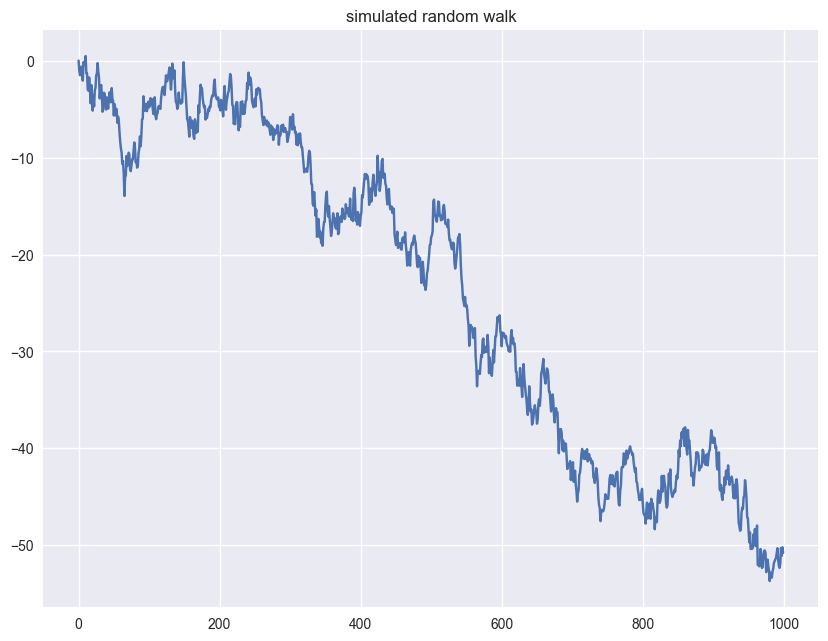

In [60]:
## random walk

points = np.random.standard_normal(1000) ## draw samples from Z(0,1)

## simulate the random walk

points[0]= 0
random_walk = np.cumsum(points)
random_walk_series = pd.Series(random_walk)
plt.figure(figsize=(10, 7.5))
plt.plot(random_walk)
plt.title("simulated random walk")
plt.show()

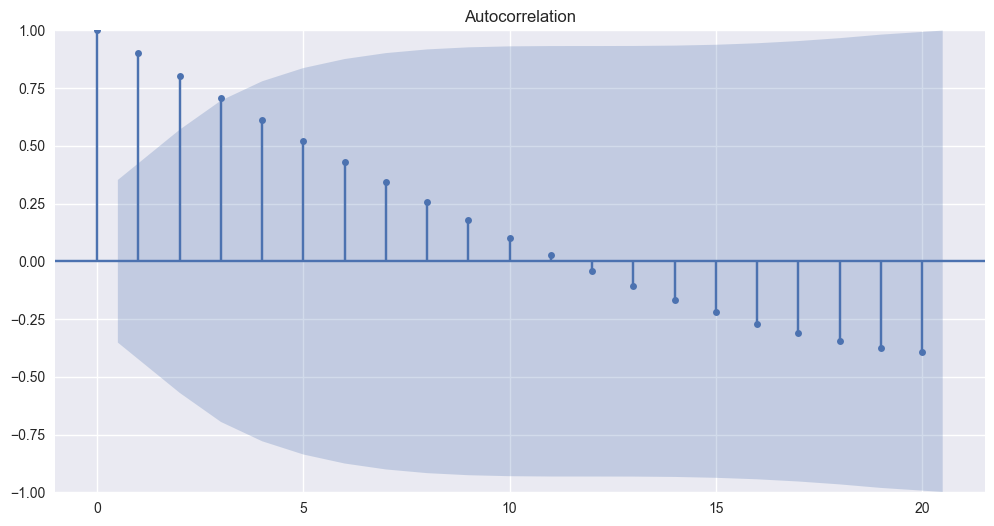

In [61]:
random_walk_acf = acf(random_walk)
acf_plot = plot_acf(random_walk_acf, lags=20)

In [62]:
## real time dataset

df = pd.read_csv("../../data/AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [63]:
# date format
df["Month"] = pd.to_datetime(df["Month"], infer_datetime_format=True)
df = df.set_index(["Month"])

In [64]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


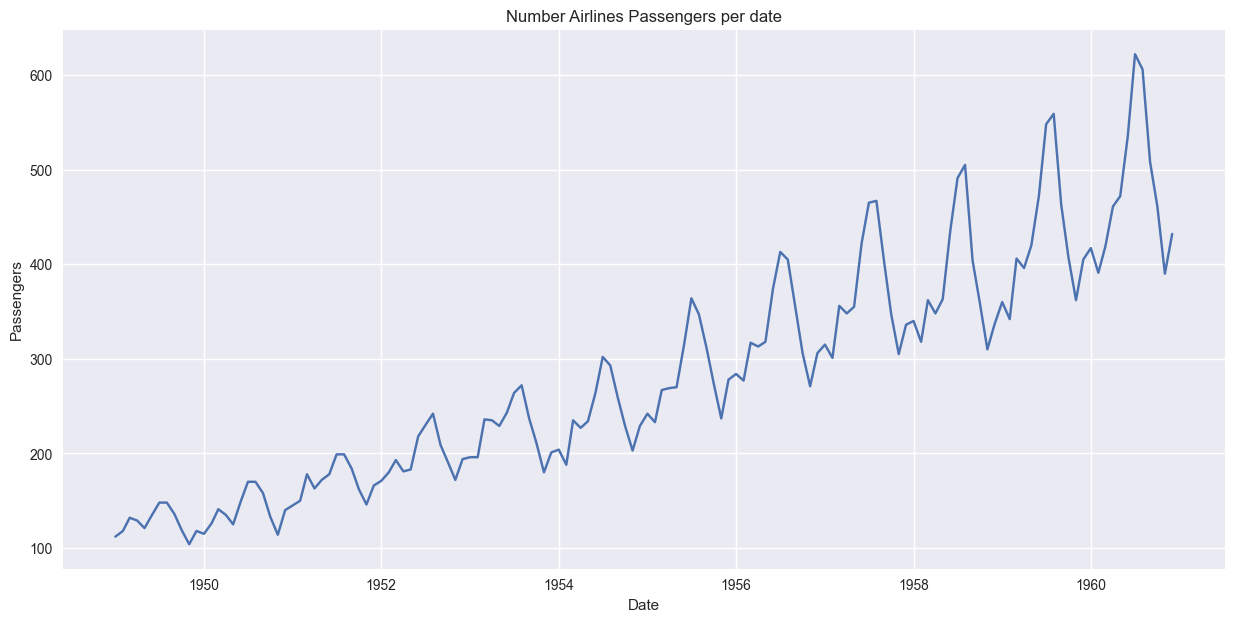

In [65]:
plt.figure(figsize=(15,7))
plt.title("Number Airlines Passengers per date")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.plot(df)
plt.show()

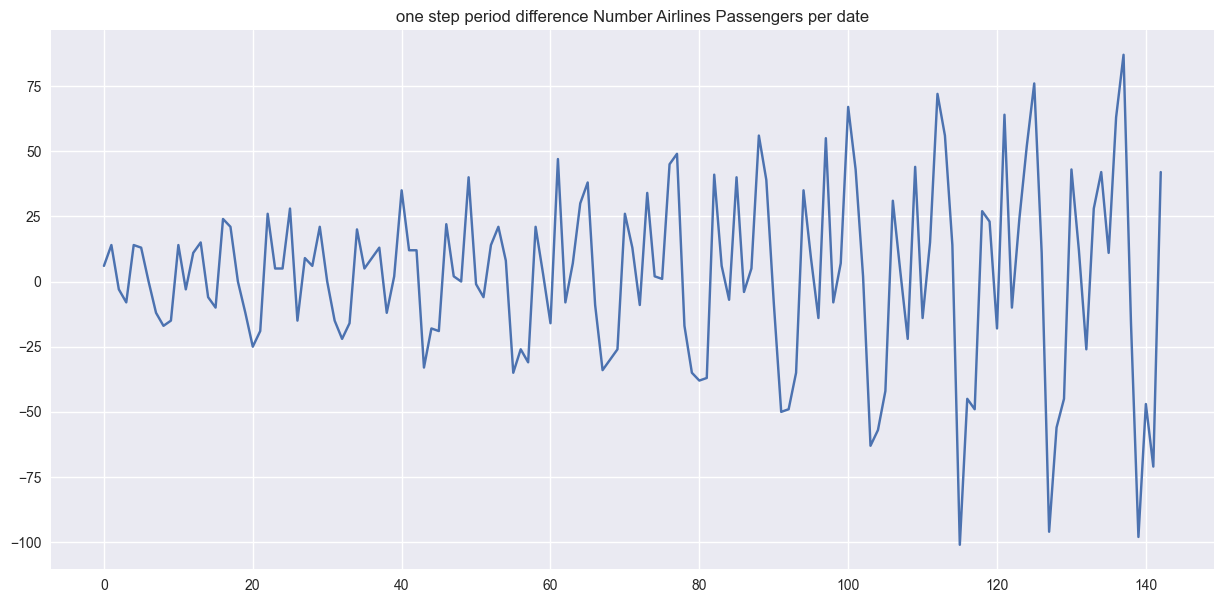

In [67]:
## difference number passengers per month
X= df["#Passengers"]
difference = np.diff(X, n=1) #X_t - X_{t-1} change of passanger numbers per month
plt.figure(figsize=(15,7))
plt.title("one step period difference Number Airlines Passengers per date")
#plt.xlabel("Date")
#plt.ylabel("Passengers")
plt.plot(difference)
plt.show()

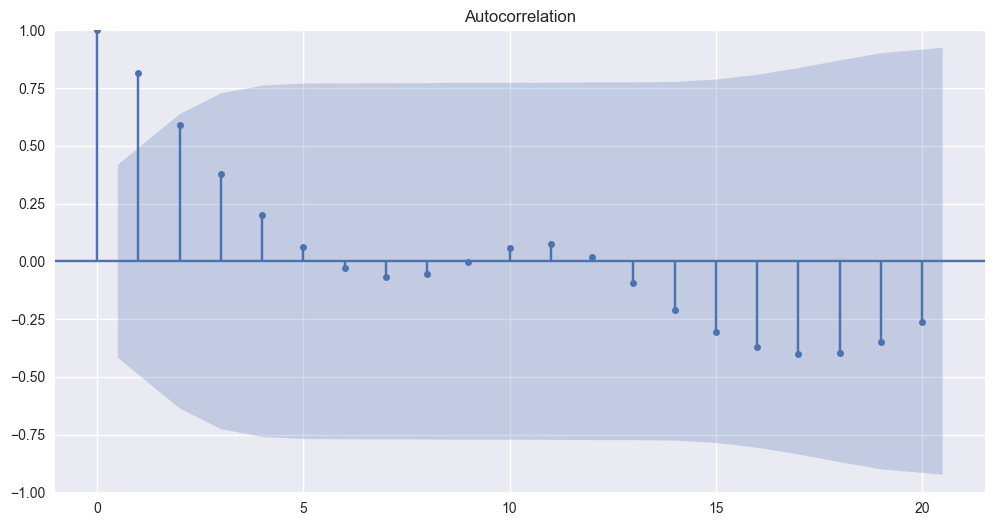

In [68]:
# autocorrelation function
X= df["#Passengers"]
passengers_acf = acf(X)
acf_plot = plot_acf(passengers_acf, lags=20)

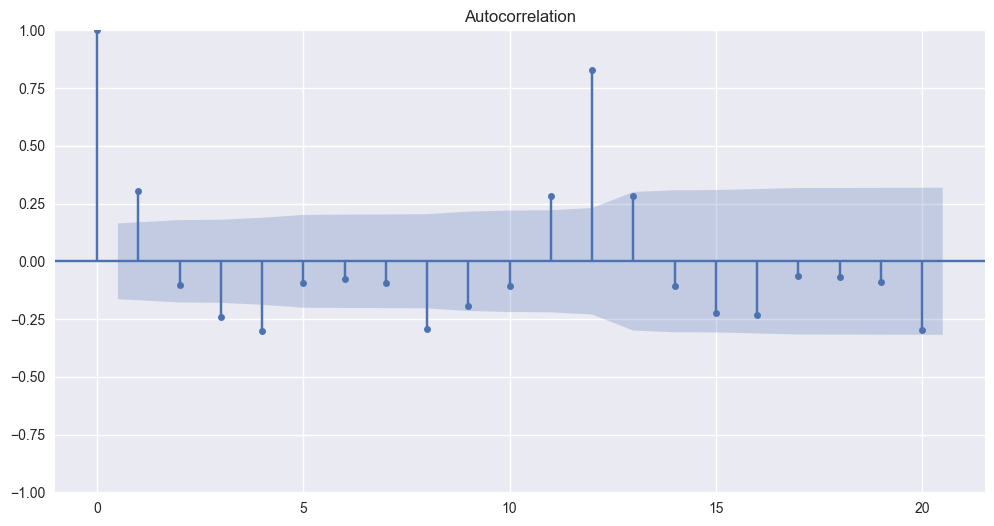

In [69]:
cof_plot_difference = plot_acf(difference, lags=20) ## difference number passengers per month
plt.show()

# Move, smoothe, evaluate

Let's start with a naive hypothesis: "tomorrow will be the same as today". However, instead of a model like $\hat{y}_{t} = y_{t-1}$ (which is actually a great baseline for any time series prediction problems and sometimes is impossible to beat), we will assume that the future value of our variable depends on the average of its $k$ previous values. Therefore, we will use the **moving average**.

$\hat{y}_{t} = \frac{1}{k} \displaystyle\sum^{k}_{n=1} y_{t-n}$

**Weighted average** is a simple modification to the moving average. The weights sum up to `1` with larger weights assigned to more recent observations.


$\hat{y}_{t} = \displaystyle\sum^{k}_{n=1} \omega_n y_{t+1-n}$

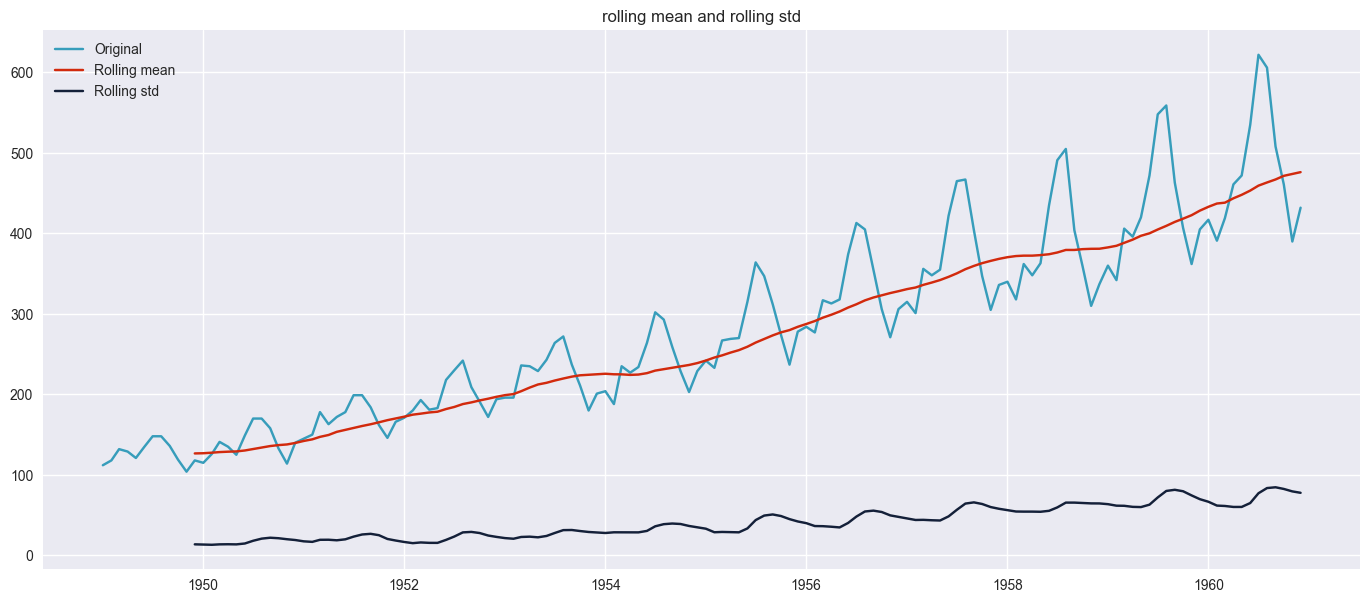

In [70]:
df["rolling_average"]= df["#Passengers"].rolling(window=12).mean()
df["rolling_std"]= df["#Passengers"].rolling(window=12).std()

#plot

plt.figure(figsize=(17,7))
plt.plot(df["#Passengers"], color = "#379DBB", label="Original")
plt.plot(df["rolling_average"], color = "#D22A0D", label="Rolling mean")
plt.plot(df["rolling_std"], color = "#142039", label="Rolling std")
plt.legend(loc="best")
plt.title("rolling mean and rolling std")
plt.show()

# Econometric approach

### Stationarity

Before we start modeling, we should mention such an important property of time series: [**stationarity**](https://en.wikipedia.org/wiki/Stationary_process).

If a process is stationary, that means it does not change its statistical properties over time, namely its mean and variance. (The constancy of variance is called [homoscedasticity](https://en.wikipedia.org/wiki/Homoscedasticity))The covariance function does not depend on time; it should only depend on the distance between observations. You can see this visually on the images in the post by [Sean Abu](http://www.seanabu.com/2016/03/22/time-series-seasonal-ARIMA-model-in-python/):

- The red graph below is not stationary because the mean increases over time.

<img src="https://habrastorage.org/files/20c/9d8/a63/20c9d8a633ec436f91dccd4aedcc6940.png"/>

- We were unlucky with the variance and see the varying spread of values over time

<img src="https://habrastorage.org/files/b88/eec/a67/b88eeca676d642449cab135273fd5a95.png"/>

- Finally, the covariance of the i th term and the (i + m) th term should not be a function of time. In the following graph, you will notice that the spread becomes closer as time increases. Hence, the covariance is not constant with time in the right chart.

<img src="https://habrastorage.org/files/2f6/1ee/cb2/2f61eecb20714352840748b826e38680.png"/>

So why is stationarity so important? Because it is easy to make predictions on a stationary series since we can assume that the future statistical properties will not be different from those currently observed. Most of the time-series models, in one way or the other, try to predict those properties (mean or variance, for example). Furture predictions would be wrong if the original series were not stationary. Unfortunately, most of the time series that we see outside of textbooks are non-stationary, but we can (and should) change this.

So, in order to combat non-stationarity, we have to know our enemy, so to speak. Let's see how we can detect it. We will look at white noise and random walks to learn how to get from one to another for free.

In [72]:
# stationarity: X_t - X_{t-1} = X_{1}- X_0 is statistically the same

# Hypothesis testing Augmented Dickey-Fuller test that challenges the null hypothesis of your data being stationary
# H0: the data is not stationary
dftest = adfuller(df["#Passengers"], autolag="AIC")
dftest
dfoutput = pd.Series(dftest[0:4], index= ["Test Statistic", "p-value", "#lags used",
                                     "number observations used"])

#for key,value in dftest[4].items():
 #   dfoutput["critical values "]= key

print(dfoutput)

Test Statistic                0.815369
p-value                       0.991880
#lags used                   13.000000
number observations used    130.000000
dtype: float64


## Exponential smoothing

Now, let's see what happens if, instead of weighting the last $k$ values of the time series, we start weighting all available observations while exponentially decreasing the weights as we move further back in time. There exists a formula for **[exponential smoothing](https://en.wikipedia.org/wiki/Exponential_smoothing)** that will help us with this:

$$\hat{y}_{t} = \alpha \cdot y_t + (1-\alpha) \cdot \hat y_{t-1} $$

Here the model value is a weighted average between the current true value and the previous model values. The $\alpha$ weight is called a smoothing factor. It defines how quickly we will "forget" the last available true observation. The smaller $\alpha$ is, the more influence the previous observations have and the smoother the series is.

Exponentiality is hidden in the recursiveness of the function -- we multiply by $(1-\alpha)$ each time, which already contains a multiplication by $(1-\alpha)$ of previous model values.

## Double exponential smoothing

Up to now, the methods that we've discussed have been for a single future point prediction (with some nice smoothing). That is cool, but it is also not enough. Let's extend exponential smoothing so that we can predict two future points (of course, we will also include more smoothing).

Series decomposition will help us -- we obtain two components: intercept (i.e. level) $\ell$ and slope (i.e. trend) $b$. We have learnt to predict intercept (or expected series value) with our previous methods; now, we will apply the same exponential smoothing to the trend by assuming that the future direction of the time series changes depends on the previous weighted changes. As a result, we get the following set of functions:

$$\ell_x = \alpha y_x + (1-\alpha)(\ell_{x-1} + b_{x-1})$$

$$b_x = \beta(\ell_x - \ell_{x-1}) + (1-\beta)b_{x-1}$$

$$\hat{y}_{x+1} = \ell_x + b_x$$

The first one describes the intercept, which, as before, depends on the current value of the series. The second term is now split into previous values of the level and of the trend. The second function describes the trend, which depends on the level changes at the current step and on the previous value of the trend. In this case, the $\beta$ coefficient is a weight for exponential smoothing. The final prediction is the sum of the model values of the intercept and trend.

In [73]:
def double_exponential_smoothing(series, alpha, beta):
    """
        series - dataset with timeseries
        alpha - float [0.0, 1.0], smoothing parameter for level
        beta - float [0.0, 1.0], smoothing parameter for trend
    """
    # first value is same as series
    result = [series[0]]
    for n in range(1, len(series)+1):
        if n == 1:
            level, trend = series[0], series[1] - series[0]
        if n >= len(series): # forecasting
            value = result[-1]
        else:
            value = series[n]
        last_level, level = level, alpha*value + (1-alpha)*(level+trend)
        trend = beta*(level-last_level) + (1-beta)*trend
        result.append(level+trend)
    return result

def plotDoubleExponentialSmoothing(series, alphas, betas):
    """
        Plots double exponential smoothing with different alphas and betas
        
        series - dataset with timestamps
        alphas - list of floats, smoothing parameters for level
        betas - list of floats, smoothing parameters for trend
    """
    
    with plt.style.context('seaborn-white'):    
        plt.figure(figsize=(20, 8))
        for alpha in alphas:
            for beta in betas:
                plt.plot(double_exponential_smoothing(series, alpha, beta), label="Alpha {}, beta {}".format(alpha, beta))
        plt.plot(series.values, label = "Actual")
        plt.legend(loc="best")
        plt.axis('tight')
        plt.title("Double Exponential Smoothing")
        plt.grid(True)

Now we have to tune two parameters: $\alpha$ and $\beta$. The former is responsible for the series smoothing around the trend, the latter for the smoothing of the trend itself. The larger the values, the more weight the most recent observations will have and the less smoothed the model series will be. Certain combinations of the parameters may produce strange results, especially if set manually. We'll look into choosing parameters automatically in a bit; before that, let's discuss triple exponential smoothing.

## Triple exponential smoothing a.k.a. Holt-Winters

We've looked at exponential smoothing and double exponential smoothing. This time, we're going into _triple_ exponential smoothing.

As you could have guessed, the idea is to add a third component - seasonality. This means that we should not use this method if our time series is not expected to have seasonality. Seasonal components in the model will explain repeated variations around intercept and trend, and it will be specified by the length of the season, in other words by the period after which the variations repeat. For each observation in the season, there is a separate component; for example, if the length of the season is 7 days (a weekly seasonality), we will have 7 seasonal components, one for each day of the week.

With this, let's write out a new system of equations:

$$\ell_x = \alpha(y_x - s_{x-L}) + (1-\alpha)(\ell_{x-1} + b_{x-1})$$

$$b_x = \beta(\ell_x - \ell_{x-1}) + (1-\beta)b_{x-1}$$

$$s_x = \gamma(y_x - \ell_x) + (1-\gamma)s_{x-L}$$

$$\hat{y}_{x+m} = \ell_x + mb_x + s_{x-L+1+(m-1)modL}$$

The intercept now depends on the current value of the series minus any corresponding seasonal component. Trend remains unchanged, and the seasonal component depends on the current value of the series minus the intercept and on the previous value of the component. Take into account that the component is smoothed through all the available seasons; for example, if we have a Monday component, then it will only be averaged with other Mondays. You can read more on how averaging works and how the initial approximation of the trend and seasonal components is done [here](http://www.itl.nist.gov/div898/handbook/pmc/section4/pmc435.htm). Now that we have the seasonal component, we can predict not just one or two steps ahead but an arbitrary $m$ future steps ahead, which is very encouraging.

Below is the code for a triple exponential smoothing model, which is also known by the last names of its creators, Charles Holt and his student Peter Winters. Additionally, the Brutlag method was included in the model to produce confidence intervals:

$$\hat y_{max_x}=\ell_{x−1}+b_{x−1}+s_{x−T}+m⋅d_{t−T}$$

$$\hat y_{min_x}=\ell_{x−1}+b_{x−1}+s_{x−T}-m⋅d_{t−T}$$

$$d_t=\gamma∣y_t−\hat y_t∣+(1−\gamma)d_{t−T},$$

where $T$ is the length of the season, $d$ is the predicted deviation. Other parameters were taken from triple exponential smoothing. You can read more about the method and its applicability to anomaly detection in time series [here](http://fedcsis.org/proceedings/2012/pliks/118.pdf).

In [ ]:
class HoltWinters:
    
    """
    Holt-Winters model with the anomalies detection using Brutlag method
    
    # series - initial time series
    # slen - length of a season
    # alpha, beta, gamma - Holt-Winters model coefficients
    # n_preds - predictions horizon
    # scaling_factor - sets the width of the confidence interval by Brutlag (usually takes values from 2 to 3)
    
    """
    
    
    def __init__(self, series, slen, alpha, beta, gamma, n_preds, scaling_factor=1.96):
        self.series = series
        self.slen = slen
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.n_preds = n_preds
        self.scaling_factor = scaling_factor
        
        
    def initial_trend(self):
        sum = 0.0
        for i in range(self.slen):
            sum += float(self.series[i+self.slen] - self.series[i]) / self.slen
        return sum / self.slen  
    
    def initial_seasonal_components(self):
        seasonals = {}
        season_averages = []
        n_seasons = int(len(self.series)/self.slen)
        # let's calculate season averages
        for j in range(n_seasons):
            season_averages.append(sum(self.series[self.slen*j:self.slen*j+self.slen])/float(self.slen))
        # let's calculate initial values
        for i in range(self.slen):
            sum_of_vals_over_avg = 0.0
            for j in range(n_seasons):
                sum_of_vals_over_avg += self.series[self.slen*j+i]-season_averages[j]
            seasonals[i] = sum_of_vals_over_avg/n_seasons
        return seasonals   

          
    def triple_exponential_smoothing(self):
        self.result = []
        self.Smooth = []
        self.Season = []
        self.Trend = []
        self.PredictedDeviation = []
        self.UpperBond = []
        self.LowerBond = []
        
        seasonals = self.initial_seasonal_components()
        
        for i in range(len(self.series)+self.n_preds):
            if i == 0: # components initialization
                smooth = self.series[0]
                trend = self.initial_trend()
                self.result.append(self.series[0])
                self.Smooth.append(smooth)
                self.Trend.append(trend)
                self.Season.append(seasonals[i%self.slen])
                
                self.PredictedDeviation.append(0)
                
                self.UpperBond.append(self.result[0] + 
                                      self.scaling_factor * 
                                      self.PredictedDeviation[0])
                
                self.LowerBond.append(self.result[0] - 
                                      self.scaling_factor * 
                                      self.PredictedDeviation[0])
                continue
                
            if i >= len(self.series): # predicting
                m = i - len(self.series) + 1
                self.result.append((smooth + m*trend) + seasonals[i%self.slen])
                
                # when predicting we increase uncertainty on each step
                self.PredictedDeviation.append(self.PredictedDeviation[-1]*1.01) 
                
            else:
                val = self.series[i]
                last_smooth, smooth = smooth, self.alpha*(val-seasonals[i%self.slen]) + (1-self.alpha)*(smooth+trend)
                trend = self.beta * (smooth-last_smooth) + (1-self.beta)*trend
                seasonals[i%self.slen] = self.gamma*(val-smooth) + (1-self.gamma)*seasonals[i%self.slen]
                self.result.append(smooth+trend+seasonals[i%self.slen])
                
                # Deviation is calculated according to Brutlag algorithm.
                self.PredictedDeviation.append(self.gamma * np.abs(self.series[i] - self.result[i]) 
                                               + (1-self.gamma)*self.PredictedDeviation[-1])
                     
            self.UpperBond.append(self.result[-1] + 
                                  self.scaling_factor * 
                                  self.PredictedDeviation[-1])

            self.LowerBond.append(self.result[-1] - 
                                  self.scaling_factor * 
                                  self.PredictedDeviation[-1])

            self.Smooth.append(smooth)
            self.Trend.append(trend)
            self.Season.append(seasonals[i%self.slen])

## Time series cross validation

Before we start building a model, let's first discuss how to estimate model parameters automatically.

There is nothing unusual here; as always, we have to choose a loss function suitable for the task that will tell us how closely the model approximates the data. Then, using cross-validation, we will evaluate our chosen loss function for the given model parameters, calculate the gradient, adjust the model parameters, and so on, eventually descending to the global minimum.

You may be asking how to do cross-validation for time series because time series have this temporal structure and one cannot randomly mix values in a fold while preserving this structure. With randomization, all time dependencies between observations will be lost. This is why we will have to use a more tricky approach in optimizing the model parameters. I don't know if there's an official name to this, but on [CrossValidated](https://stats.stackexchange.com/questions/14099/using-k-fold-cross-validation-for-time-series-model-selection), where one can find all answers but the Answer to the Ultimate Question of Life, the Universe, and Everything, the proposed name for this method is "cross-validation on a rolling basis".

The idea is rather simple -- we train our model on a small segment of the time series from the beginning until some $t$, make predictions for the next $t+n$ steps, and calculate an error. Then, we expand our training sample to $t+n$ value, make predictions from $t+n$ until $t+2*n$, and continue moving our test segment of the time series until we hit the last available observation. As a result, we have as many folds as $n$ will fit between the initial training sample and the last observation.

<img src="https://habrastorage.org/files/f5c/7cd/b39/f5c7cdb39ccd4ba68378ca232d20d864.png"/>

Now, knowing how to set up cross-validation, we can find the optimal parameters for the Holt-Winters model. Recall that we have daily seasonality in ads, hence the `slen=24` parameter.

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit # you have everything done for you

def timeseriesCVscore(params, series, loss_function=mean_squared_error, slen=24):
    """
        Returns error on CV  
        
        params - vector of parameters for optimization
        series - dataset with timeseries
        slen - season length for Holt-Winters model
    """
    # errors array
    errors = []
    
    values = series.values
    alpha, beta, gamma = params
    
    # set the number of folds for cross-validation
    tscv = TimeSeriesSplit(n_splits=3) 
    
    # iterating over folds, train model on each, forecast and calculate error
    for train, test in tscv.split(values):

        model = HoltWinters(series=values[train], slen=slen, 
                            alpha=alpha, beta=beta, gamma=gamma, n_preds=len(test))
        model.triple_exponential_smoothing()
        
        predictions = model.result[-len(test):]
        actual = values[test]
        error = loss_function(predictions, actual)
        errors.append(error)
        
    return np.mean(np.array(errors))

In [ ]:
def plotHoltWinters(series, plot_intervals=False, plot_anomalies=False):
    """
        series - dataset with timeseries
        plot_intervals - show confidence intervals
        plot_anomalies - show anomalies 
    """
    
    plt.figure(figsize=(20, 10))
    plt.plot(model.result, label = "Model")
    plt.plot(series.values, label = "Actual")
    error = mean_absolute_percentage_error(series.values, model.result[:len(series)])
    plt.title("Mean Absolute Percentage Error: {0:.2f}%".format(error))
    
    if plot_anomalies:
        anomalies = np.array([np.NaN]*len(series))
        anomalies[series.values<model.LowerBond[:len(series)]] = \
            series.values[series.values<model.LowerBond[:len(series)]]
        anomalies[series.values>model.UpperBond[:len(series)]] = \
            series.values[series.values>model.UpperBond[:len(series)]]
        plt.plot(anomalies, "o", markersize=10, label = "Anomalies")
    
    if plot_intervals:
        plt.plot(model.UpperBond, "r--", alpha=0.5, label = "Up/Low confidence")
        plt.plot(model.LowerBond, "r--", alpha=0.5)
        plt.fill_between(x=range(0,len(model.result)), y1=model.UpperBond, 
                         y2=model.LowerBond, alpha=0.2, color = "grey")    
        
    plt.vlines(len(series), ymin=min(model.LowerBond), ymax=max(model.UpperBond), linestyles='dashed')
    plt.axvspan(len(series)-20, len(model.result), alpha=0.3, color='lightgrey')
    plt.grid(True)
    plt.axis('tight')
    plt.legend(loc="best", fontsize=13);

In [ ]:
def plotHoltWinters(series, plot_intervals=False, plot_anomalies=False):
    """
        series - dataset with timeseries
        plot_intervals - show confidence intervals
        plot_anomalies - show anomalies 
    """
    
    plt.figure(figsize=(20, 10))
    plt.plot(model.result, label = "Model")
    plt.plot(series.values, label = "Actual")
    error = mean_absolute_percentage_error(series.values, model.result[:len(series)])
    plt.title("Mean Absolute Percentage Error: {0:.2f}%".format(error))
    
    if plot_anomalies:
        anomalies = np.array([np.NaN]*len(series))
        anomalies[series.values<model.LowerBond[:len(series)]] = \
            series.values[series.values<model.LowerBond[:len(series)]]
        anomalies[series.values>model.UpperBond[:len(series)]] = \
            series.values[series.values>model.UpperBond[:len(series)]]
        plt.plot(anomalies, "o", markersize=10, label = "Anomalies")
    
    if plot_intervals:
        plt.plot(model.UpperBond, "r--", alpha=0.5, label = "Up/Low confidence")
        plt.plot(model.LowerBond, "r--", alpha=0.5)
        plt.fill_between(x=range(0,len(model.result)), y1=model.UpperBond, 
                         y2=model.LowerBond, alpha=0.2, color = "grey")    
        
    plt.vlines(len(series), ymin=min(model.LowerBond), ymax=max(model.UpperBond), linestyles='dashed')
    plt.axvspan(len(series)-20, len(model.result), alpha=0.3, color='lightgrey')
    plt.grid(True)
    plt.axis('tight')
    plt.legend(loc="best", fontsize=13)

## ARIMA-family Crash-Course

We will explain this model by building up letter by letter. $SARIMA(p, d, q)(P, D, Q, s)$, Seasonal Autoregression Moving Average model:

- $AR(p)$ - autoregression model i.e. regression of the time series onto itself. The basic assumption is that the current series values depend on its previous values with some lag (or several lags). The maximum lag in the model is referred to as $p$. To determine the initial $p$, you need to look at the PACF plot and find the biggest significant lag after which **most** other lags become insignificant.
- $MA(q)$ - moving average model. Without going into too much detail, this models the error of the time series, again with the assumption that the current error depends on the previous with some lag, which is referred to as $q$. The initial value can be found on the ACF plot with the same logic as before. 

Let's combine our first 4 letters:

$AR(p) + MA(q) = ARMA(p, q)$

What we have here is the Autoregressive–moving-average model! If the series is stationary, it can be approximated with these 4 letters. Let's continue.

- $I(d)$ - order of integration. This is simply the number of nonseasonal differences needed to make the series stationary. In our case, it's just 1 because we used first differences. 

Adding this letter to the four gives us the $ARIMA$ model which can handle non-stationary data with the help of nonseasonal differences. Great, one more letter to go!

- $S(s)$ - this is responsible for seasonality and equals the season period length of the series

With this, we have three parameters: $(P, D, Q)$

- $P$ - order of autoregression for the seasonal component of the model, which can be derived from PACF. But you need to look at the number of significant lags, which are the multiples of the season period length. For example, if the period equals 24 and we see the 24-th and 48-th lags are significant in the PACF, that means the initial $P$ should be 2.

- $Q$ - similar logic using the ACF plot instead.

- $D$ - order of seasonal integration. This can be equal to 1 or 0, depending on whether seasonal differeces were applied or not.

## Getting rid of non-stationarity and building SARIMA

Let's build an ARIMA model by walking through all the ~~circles of hell~~ stages of making a series stationary.

Here is the code to render plots.

In [ ]:

def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    """
        Plot time series, its ACF and PACF, calculate Dickey–Fuller test
        
        y - timeseries
        lags - how many lags to include in ACF, PACF calculation
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

In [ ]:
def optimizeSARIMA(parameters_list, d, D, s):
    """
        Return dataframe with parameters and corresponding AIC
        
        parameters_list - list with (p, q, P, Q) tuples
        d - integration order in ARIMA model
        D - seasonal integration order 
        s - length of season
    """
    
    results = []
    best_aic = float("inf")

    for param in tqdm_notebook(parameters_list):
        # we need try-except because on some combinations model fails to converge
        try:
            model=sm.tsa.statespace.SARIMAX(ads.Ads, order=(param[0], d, param[1]), 
                                            seasonal_order=(param[2], D, param[3], s)).fit(disp=-1)
        except:
            continue
        aic = model.aic
        # saving best model, AIC and parameters
        if aic < best_aic:
            best_model = model
            best_aic = aic
            best_param = param
        results.append([param, model.aic])

    result_table = pd.DataFrame(results)
    result_table.columns = ['parameters', 'aic']
    # sorting in ascending order, the lower AIC is - the better
    result_table = result_table.sort_values(by='aic', ascending=True).reset_index(drop=True)
    
    return result_table

In [ ]:
def plotSARIMA(series, model, n_steps):
    """
        Plots model vs predicted values
        
        series - dataset with timeseries
        model - fitted SARIMA model
        n_steps - number of steps to predict in the future
        
    """
    # adding model values
    data = series.copy()
    data.columns = ['actual']
    data['arima_model'] = model.fittedvalues
    # making a shift on s+d steps, because these values were unobserved by the model
    # due to the differentiating
    data['arima_model'][:s+d] = np.NaN
    
    # forecasting on n_steps forward 
    forecast = model.predict(start = data.shape[0], end = data.shape[0]+n_steps)
    forecast = data.arima_model.append(forecast)
    # calculate error, again having shifted on s+d steps from the beginning
    error = mean_absolute_percentage_error(data['actual'][s+d:], data['arima_model'][s+d:])

    plt.figure(figsize=(15, 7))
    plt.title("Mean Absolute Percentage Error: {0:.2f}%".format(error))
    plt.plot(forecast, color='r', label="model")
    plt.axvspan(data.index[-1], forecast.index[-1], alpha=0.5, color='lightgrey')
    plt.plot(data.actual, label="actual")
    plt.legend()
    plt.grid(True);

# <center>Time Series Forecasting w/ ARIMA</center>


#### Links + Resources

Throughout the notebook I implement and reword ideas from the following sources. Thank you to all for sharing!

[A Deep Dive on Arima Models](https://towardsdatascience.com/a-deep-dive-on-arima-models-8900c199ccf) - by Matt Sosna <-- MUST READ!

[Time Series For beginners with ARIMA](https://www.kaggle.com/freespirit08/time-series-for-beginners-with-arima/notebook) - by [@Arindam Chatterjee](https://www.kaggle.com/freespirit08)

[Arima Model for Time Series Forecasting](https://www.kaggle.com/prashant111/arima-model-for-time-series-forecasting#14.-SARIMA-model-in-python-) - by [@Prashant Banerjee](https://www.kaggle.com/prashant111)

[StatsModels ADF Documentation](https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html?highlight=augmented%20dickey%20fuller%20test)

[Removing Trends and Seasonality Article](https://machinelearningmastery.com/remove-trends-seasonality-difference-transform-python/) - by Jason Brownlee

[A Gentle Introduction to SARIMA](https://machinelearningmastery.com/sarima-for-time-series-forecasting-in-python/) - by Jason Brownlee

---

## <center>ARIMA</center>

The ARIMA model stands for "Auto-Regressive Integrated Moving Average" and can be broken down into AR, I, MA.

This section is [a-deep-dive-on-arima-models](https://towardsdatascience.com/a-deep-dive-on-arima-models-8900c199ccf) yet in my own words. Thanks to Matt Sosna for sharing this amazing article and for the images!

---

### <center>Autoregressive Component - AR(p)</center>

The autoregressive component of the ARIMA model is represented by AR(p), with the p parameter determining the number of lagged series that we use.

<p align="center">
  <img src="https://miro.medium.com/max/1400/1*8If_nqKxNbzd3JPZAXICVg.png" />
</p>

#### AR(0): White Noise

- If we set the p parameter as zero (AR(0)), with no autoregressive terms. This time series is just white noise.

- Each data point is sampled from a distribution with a mean of 0 and a variance of sigma-squared. 

- This results in a sequence of random numbers that can't be predicted. 

- This is really useful as it can serve as a null hypothesis, and protect our analyses from accepting false-positive patterns.

#### AR(1): Random Walks and Oscillations

- With the p parameter set to 1, we are taking into account the previous timestamp adjusted by a multiplier, and then adding white noise.

- If the multiplier is 0 then we get white noise, and if the multiplier is 1 we get a random walk. 

- If the multiplier is between 0 < α₁ < 1, then the time series will exhibit mean reversion. This means that the values tend to hover around 0 and revert to the mean after regressing from it.

#### AR(p): Higher-order terms

- Increasing the p parameter even further is just means going further back and adding more timestamps adjusted by their own multipliers.

- We can go as far back as we want, but as we get further back it is more likely that we should use additional parameters such as the moving average (MA(q)).

---

### <center>Moving Average - MA(q)</center>


#### MA(q)

- MA(q) is the moving average model and q is the number of lagged forecasting error terms in the prediction.

- In an MA(1) model, our forecast is a constant term plus the previous white noise term times a multiplier, added with the current white noise term.

- This is just simple probability + statistics, as we are adjusting our forecast based on previous white noise terms.

## <center>ARMA and ARIMA Models</center>

ARMA and ARIMA architectures are just the AR (Autoregressive) and MA (Moving Average) components put together.

#### ARMA

The ARMA model is a constant plus the sum of AR lags and their multipliers, plus the sum of the MA lags and their multipliers plus white noise. This equation is the basis of all the models that come next and is a framework for many forecasting models across different domains. 

#### ARIMA

<p align="center">
  <img src="https://miro.medium.com/max/1400/1*t2vQXShddn_RNJno_oSgIQ.png" />
</p>

- The ARIMA model is an ARMA model yet with a preprocessing step included in the model that we represent using I(d).

- I(d) is the difference order, which is the number of transformations needed to make the data stationary.

- So, an ARIMA model is simply an ARMA model on the differenced time series.

## <center>SARIMA, ARIMAX, SARIMAX Models</center>

The ARIMA model is great, but to include seasonality and exogenous variables in the model can be extremely powerful. Since the ARIMA model assumes that the time series is stationary, we need to use a different model.

#### SARIMA

<p align="center">
  <img src="https://miro.medium.com/max/1400/1*feNkO5nl2ET5EXZ2vG8mQg.png" />
</p>

- Enter SARIMA (Seasonal ARIMA). This model is very similar to the ARIMA model, except that there is an additional set of autoregressive and moving average components. 

- These additional lags are offset by the frequency of seasonality (ex. 12 - monthly, 24 - hourly).

- SARIMA models allow for differencing data by seasonal frequency, yet also by non-seasonal differencing. 

- Knowing which parameters are best can be made easier through automatic parameter search frameworks such as `pmdarima`

#### ARIMAX and SARIMAX

<p align="center">
  <img src="https://miro.medium.com/max/1400/1*wdyr2r-FSIncbHXQTbpZaQ.png" />
</p>

- The final version of the ARMA model is the ARIMAX and SARIMAX models. 

- These models take into account exogenous variables, or in other words, use external data in our forecast.

- Some real-world examples of exogenous variables include gold price, oil price, outdoor temperature, exchange rate.

- It is interesting to think that all exogenous factors are still technically indirectly modeled in the historical model forecast. That being said, if we include external data, we will respond much quicker to that than if we rely on the influence of lagging terms.

# ARIMA family of models

## 1. ARMA model (Autoregressive Moving Average Model)

* AR(p): autoregressive component that actually assumes that the current state of the series depends on its previous values
with some lag p (the maximum period)
* MA(q): moving average model with some lag q
ARMA = AR+ MA

# 2. ARIMA model (Autoregressive Integrated Moving Average Model)
* AR(p)
* MA(q)
* I(d) : to model the number of non seasonal differences needed to make the series stationary
ARIMA = AR(p) + MA(q) + I(d)

# 3. SARIMA model (Seasonal Autoregressive Moving Average Model)
* AR(p)
* MA(q)
* I(d)
* S(s): responsable for the seasonality and equals the season period length of the series

# Time Series Analysis: Classical and ML Approaches
## A Workshop on Airline Passengers Data

### Workshop Overview
This notebook covers two main approaches to time series forecasting:
1. **Classical Methods**: ARIMA, SARIMA, and Double Exponential Smoothing
2. **Machine Learning Methods**: Feature engineering and XGBoost with proper time series cross-validation

**Dataset**: Monthly airline passengers (1949-1960) - a classic time series with trend and seasonality.

---

## Setup and Data Loading

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Statistical libraries
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ML libraries
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Visualization
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)

In [75]:
# real dataset life

# Load the airline passengers dataset
# This dataset contains monthly totals of airline passengers from 1949-1960
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Data preprocessing
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())


Dataset shape: (144, 1)

First few rows:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


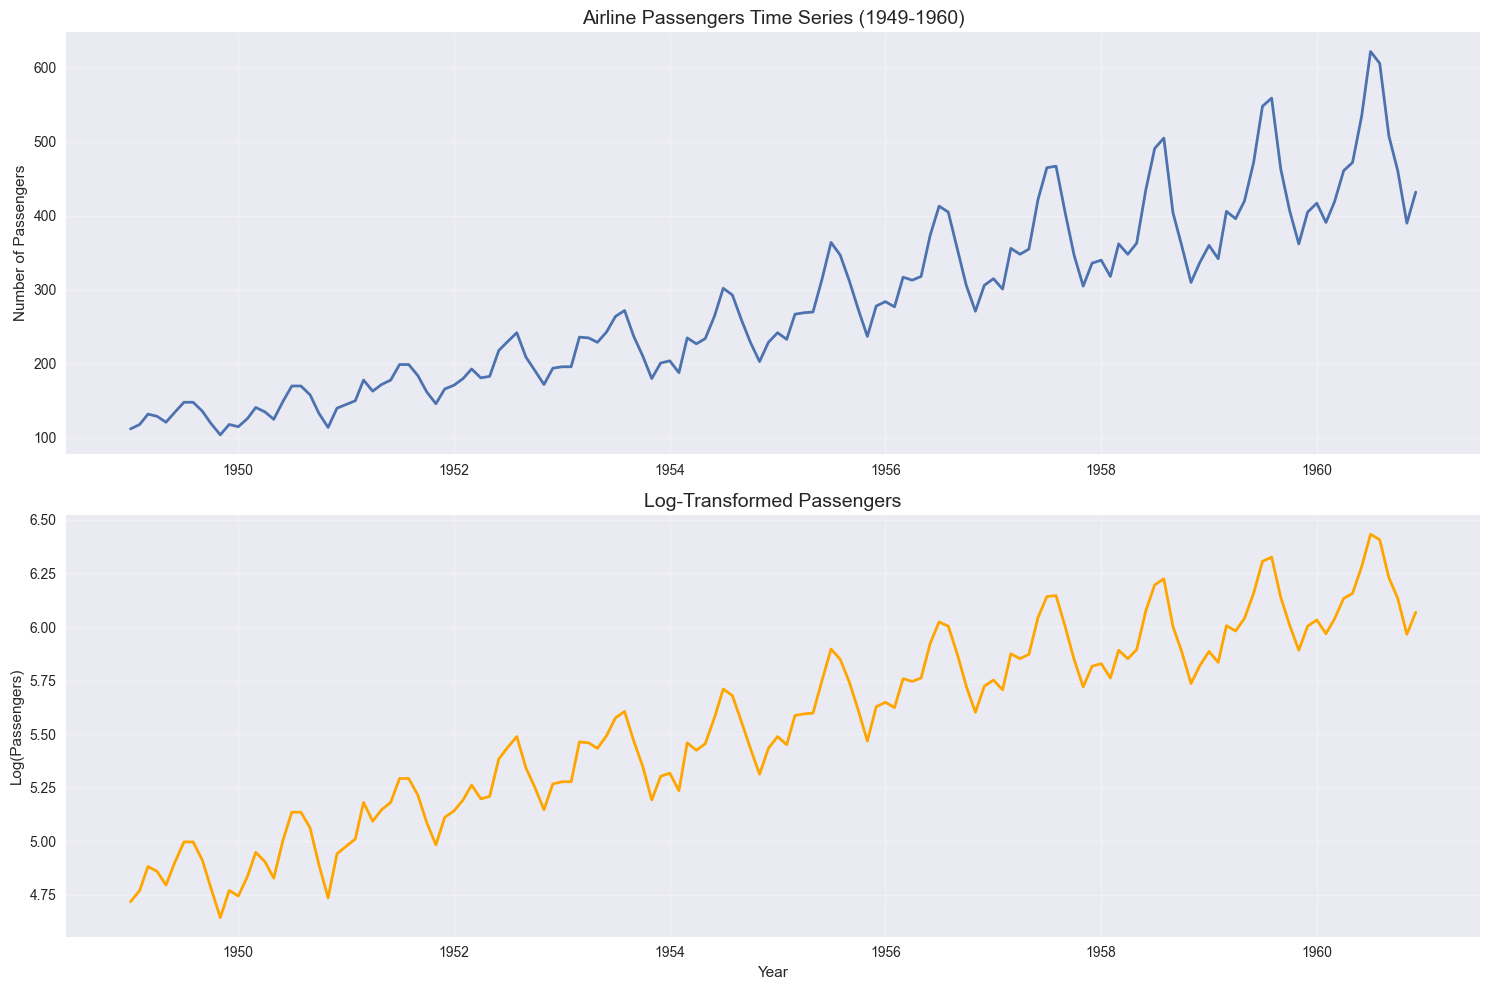

In [76]:
# Initial visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Original time series
axes[0].plot(df.index, df['Passengers'], linewidth=2)
axes[0].set_title('Airline Passengers Time Series (1949-1960)', fontsize=14)
axes[0].set_ylabel('Number of Passengers')
axes[0].grid(True, alpha=0.3)

# Log transformation to stabilize variance
df['Log_Passengers'] = np.log(df['Passengers'])
axes[1].plot(df.index, df['Log_Passengers'], linewidth=2, color='orange')
axes[1].set_title('Log-Transformed Passengers', fontsize=14)
axes[1].set_ylabel('Log(Passengers)')
axes[1].set_xlabel('Year')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 1: Classical Time Series Methods (60 minutes)

### 1.1 Time Series Decomposition

Understanding the components of our time series is crucial for selecting appropriate models.


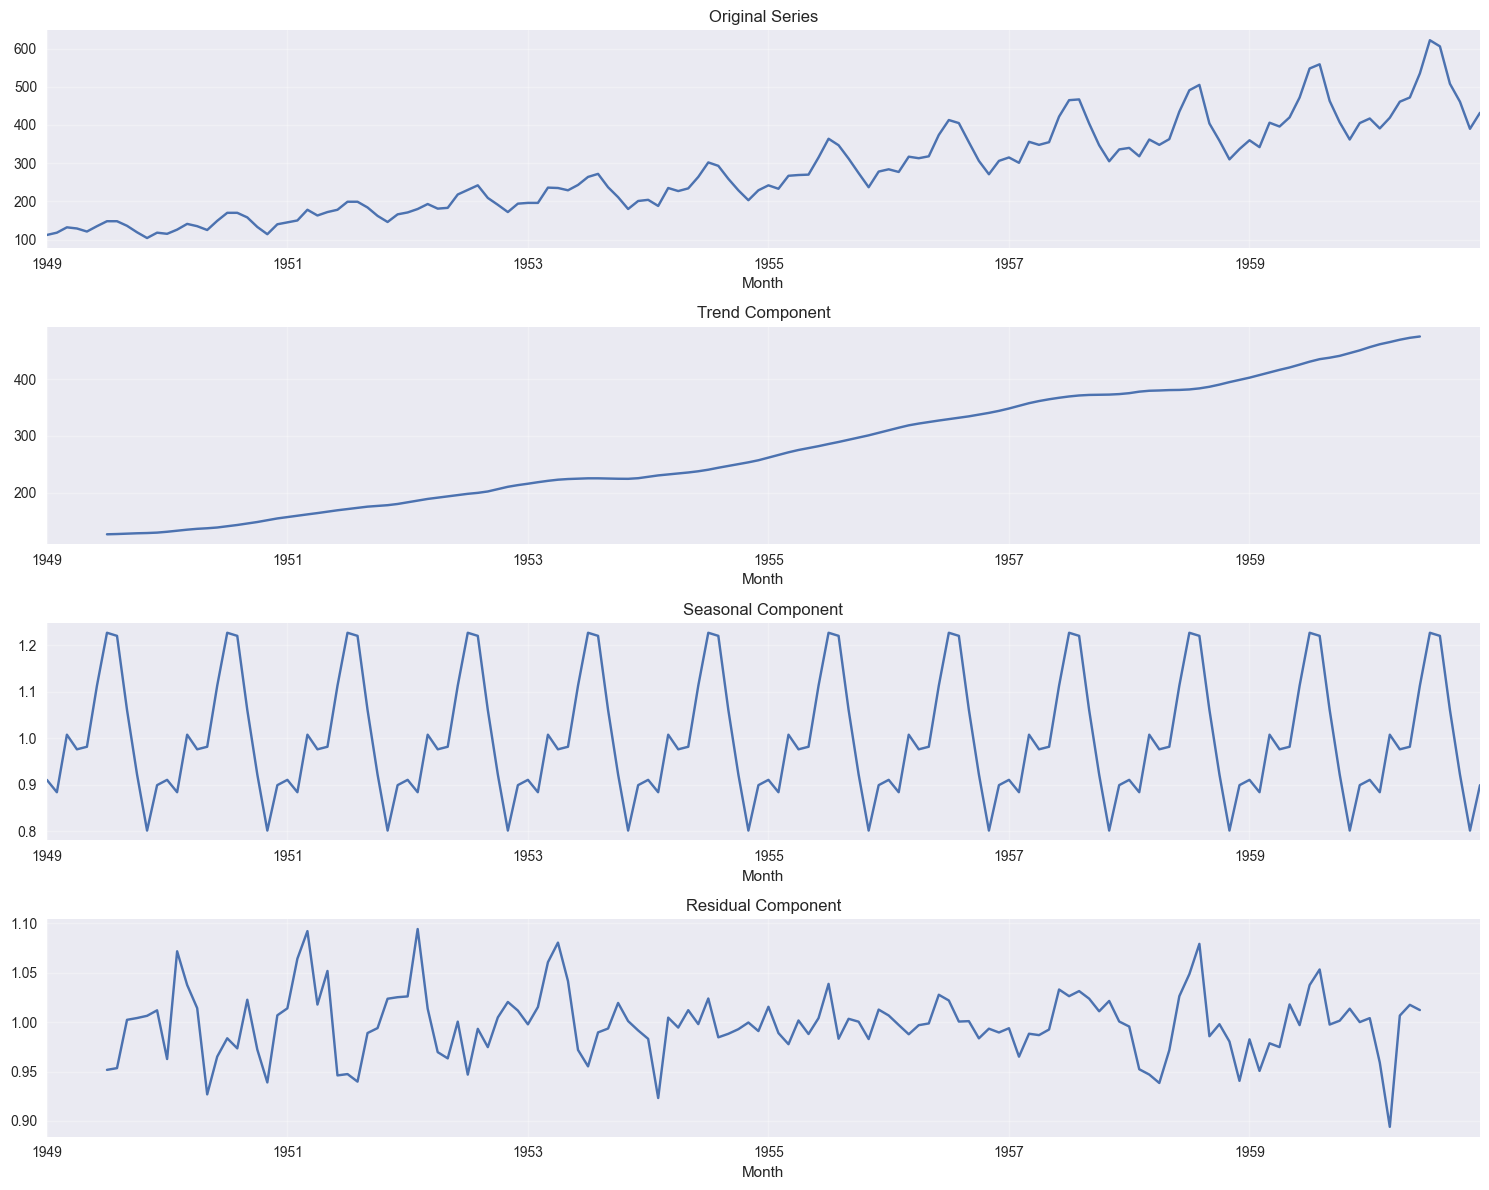

Key Observations:
1. Clear upward trend
2. Strong seasonal pattern (12-month cycle)
3. Increasing variance over time (multiplicative seasonality)


In [77]:
# Decompose the time series
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomposition.observed.plot(ax=axes[0], title='Original Series')
decomposition.trend.plot(ax=axes[1], title='Trend Component')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component')
decomposition.resid.plot(ax=axes[3], title='Residual Component')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("1. Clear upward trend")
print("2. Strong seasonal pattern (12-month cycle)")
print("3. Increasing variance over time (multiplicative seasonality)")

## 1.2 Stationarity Testing

Before applying ARIMA models, we need to check and achieve stationarity.

In [78]:
def check_stationarity(timeseries, title="Time Series"):
    """
    Perform Augmented Dickey-Fuller test for stationarity
    """
    print(f"=== Stationarity Test for {title} ===")
    
    # Perform ADF test
    result = adfuller(timeseries.dropna())
    
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print("✅ Series is stationary (reject null hypothesis)")
    else:
        print("❌ Series is non-stationary (fail to reject null hypothesis)")
    print()

In [79]:
# Test original series
check_stationarity(df['Passengers'], "Original Series")

# Apply first differencing
df['Passengers_diff1'] = df['Passengers'].diff()
check_stationarity(df['Passengers_diff1'], "First Difference")

# Apply seasonal differencing
df['Passengers_seasonal_diff'] = df['Passengers'].diff(12)
check_stationarity(df['Passengers_seasonal_diff'], "Seasonal Difference (12)")

# Apply both first and seasonal differencing
df['Passengers_diff1_seasonal'] = df['Passengers'].diff().diff(12)
check_stationarity(df['Passengers_diff1_seasonal'], "First + Seasonal Difference")

=== Stationarity Test for Original Series ===
ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579
❌ Series is non-stationary (fail to reject null hypothesis)

=== Stationarity Test for First Difference ===
ADF Statistic: -2.829267
p-value: 0.054213
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579
❌ Series is non-stationary (fail to reject null hypothesis)

=== Stationarity Test for Seasonal Difference (12) ===
ADF Statistic: -3.383021
p-value: 0.011551
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579
✅ Series is stationary (reject null hypothesis)

=== Stationarity Test for First + Seasonal Difference ===
ADF Statistic: -15.595618
p-value: 0.000000
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579
✅ Series is stationary (reject null hypothesis)



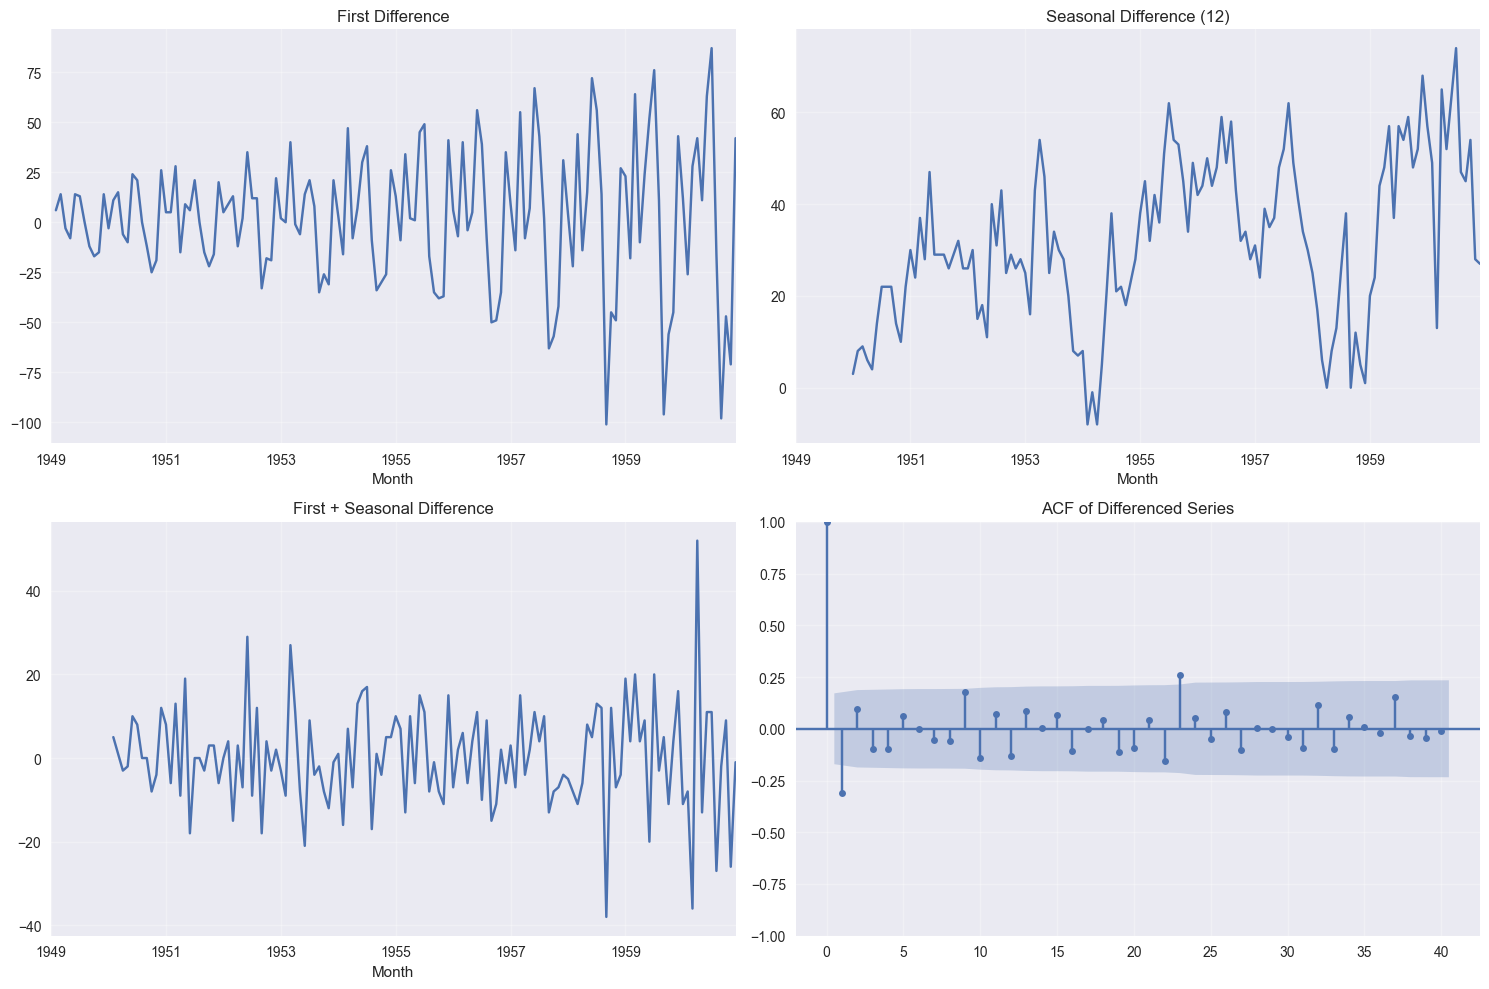

In [80]:
# Visualize differenced series
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df['Passengers_diff1'].plot(ax=axes[0,0], title='First Difference')
df['Passengers_seasonal_diff'].plot(ax=axes[0,1], title='Seasonal Difference (12)')
df['Passengers_diff1_seasonal'].plot(ax=axes[1,0], title='First + Seasonal Difference')

# ACF and PACF of the stationary series
plot_acf(df['Passengers_diff1_seasonal'].dropna(), ax=axes[1,1], lags=40, title='ACF of Differenced Series')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1.3 ARIMA Model

ARIMA(p,d,q) models are fundamental for time series forecasting.

**Theory**: 
- **AR(p)**: Autoregressive component - uses past values
- **I(d)**: Integrated component - differencing to achieve stationarity  
- **MA(q)**: Moving average component - uses past forecast errors

In [81]:
def find_best_arima_params(data, max_p=5, max_d=2, max_q=5):
    """
    Grid search for best ARIMA parameters using AIC
    """
    best_aic = float('inf')
    best_params = None
    
    print("Searching for optimal ARIMA parameters...")
    
    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                try:
                    model = ARIMA(data, order=(p, d, q))
                    fitted_model = model.fit()
                    aic = fitted_model.aic
                    
                    if aic < best_aic:
                        best_aic = aic
                        best_params = (p, d, q)
                        
                except:
                    continue
    
    print(f"Best ARIMA parameters: {best_params}")
    print(f"Best AIC: {best_aic:.2f}")
    return best_params

# Find optimal parameters
best_arima_params = find_best_arima_params(df['Passengers'])

Searching for optimal ARIMA parameters...
Best ARIMA parameters: (5, 1, 5)
Best AIC: 1335.12


In [82]:
# Fit ARIMA model with best parameters
arima_model = ARIMA(df['Passengers'], order=best_arima_params)
arima_fitted = arima_model.fit()

print("ARIMA Model Summary:")
print(arima_fitted.summary())

# Generate forecasts
forecast_steps = 24
arima_forecast = arima_fitted.forecast(steps=forecast_steps)
arima_conf_int = arima_fitted.get_forecast(steps=forecast_steps).conf_int()

# Create forecast dates
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                               periods=forecast_steps, freq='M')

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(5, 1, 5)   Log Likelihood                -656.560
Date:                Sat, 16 Aug 2025   AIC                           1335.120
Time:                        12:55:06   BIC                           1367.711
Sample:                    01-01-1949   HQIC                          1348.363
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5357      0.207      2.584      0.010       0.129       0.942
ar.L2         -0.1099      0.185     -0.593      0.553      -0.473       0.253
ar.L3          0.4102      0.18

In [83]:
# Create forecast dates
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                               periods=forecast_steps, freq='M')

### 1.4 SARIMA Model

SARIMA extends ARIMA to handle seasonal patterns explicitly.

**SARIMA(p,d,q)(P,D,Q)s**: Adds seasonal components
- **(P,D,Q)**: Seasonal AR, differencing, and MA terms
- **s**: Seasonal period (12 for monthly data)

In [84]:
def find_best_sarima_params(data, seasonal_period=12, max_order=2):
    """
    Grid search for optimal SARIMA parameters
    """
    best_aic = float('inf')
    best_params = None
    
    print("Searching for optimal SARIMA parameters...")
    
    # Limit search space for computational efficiency
    param_combinations = [
        (1,1,1), (1,1,2), (2,1,1), (2,1,2),
        (1,0,1), (1,0,2), (2,0,1), (2,0,2)
    ]
    
    seasonal_combinations = [
        (1,1,1), (1,1,2), (2,1,1), (0,1,1), (1,1,0)
    ]
    
    for param in param_combinations:
        for seasonal_param in seasonal_combinations:
            try:
                model = SARIMAX(data, 
                               order=param,
                               seasonal_order=seasonal_param + (seasonal_period,))
                fitted_model = model.fit(disp=False)
                aic = fitted_model.aic
                
                if aic < best_aic:
                    best_aic = aic
                    best_params = (param, seasonal_param + (seasonal_period,))
                    
            except:
                continue
    
    print(f"Best SARIMA parameters: {best_params}")
    print(f"Best AIC: {best_aic:.2f}")
    return best_params

# Find optimal SARIMA parameters
best_sarima_params = find_best_sarima_params(df['Passengers'])



Searching for optimal SARIMA parameters...
Best SARIMA parameters: ((2, 1, 1), (1, 1, 2, 12))
Best AIC: 1012.09


In [85]:
# Fit SARIMA model
sarima_model = SARIMAX(df['Passengers'], 
                       order=best_sarima_params[0],
                       seasonal_order=best_sarima_params[1])
sarima_fitted = sarima_model.fit(disp=False)

print("SARIMA Model Summary:")
print(sarima_fitted.summary())

# Generate SARIMA forecasts
sarima_forecast = sarima_fitted.forecast(steps=forecast_steps)
sarima_conf_int = sarima_fitted.get_forecast(steps=forecast_steps).conf_int()

SARIMA Model Summary:
                                        SARIMAX Results                                        
Dep. Variable:                              Passengers   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                -499.043
Date:                                 Sat, 16 Aug 2025   AIC                           1012.085
Time:                                         12:56:49   BIC                           1032.211
Sample:                                     01-01-1949   HQIC                          1020.263
                                          - 12-01-1960                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5266      0.080      6.589      0.0

### 1.5 Double Exponential Smoothing (Holt-Winters)

Exponential smoothing methods are intuitive and effective for seasonal data.

**Theory**:
- **Simple**: Only level (α)
- **Double (Holt)**: Level (α) + Trend (β)
- **Triple (Holt-Winters)**: Level (α) + Trend (β) + Seasonality (γ)

In [86]:
# Fit Holt-Winters model
# Using both additive and multiplicative seasonality
hw_add_model = ExponentialSmoothing(df['Passengers'], 
                                    trend='add', 
                                    seasonal='add', 
                                    seasonal_periods=12)
hw_add_fitted = hw_add_model.fit()

hw_mult_model = ExponentialSmoothing(df['Passengers'], 
                                     trend='add', 
                                     seasonal='mul', 
                                     seasonal_periods=12)
hw_mult_fitted = hw_mult_model.fit()

# Generate forecasts
hw_add_forecast = hw_add_fitted.forecast(steps=forecast_steps)
hw_mult_forecast = hw_mult_fitted.forecast(steps=forecast_steps)

print("Holt-Winters Model Parameters:")
print(f"Additive - α: {hw_add_fitted.params['smoothing_level']:.4f}, "
      f"β: {hw_add_fitted.params['smoothing_trend']:.4f}, "
      f"γ: {hw_add_fitted.params['smoothing_seasonal']:.4f}")
print(f"Multiplicative - α: {hw_mult_fitted.params['smoothing_level']:.4f}, "
      f"β: {hw_mult_fitted.params['smoothing_trend']:.4f}, "
      f"γ: {hw_mult_fitted.params['smoothing_seasonal']:.4f}")


Holt-Winters Model Parameters:
Additive - α: 0.2526, β: 0.0000, γ: 0.7474
Multiplicative - α: 0.3186, β: 0.0000, γ: 0.6014


### 1.6 Model Comparison


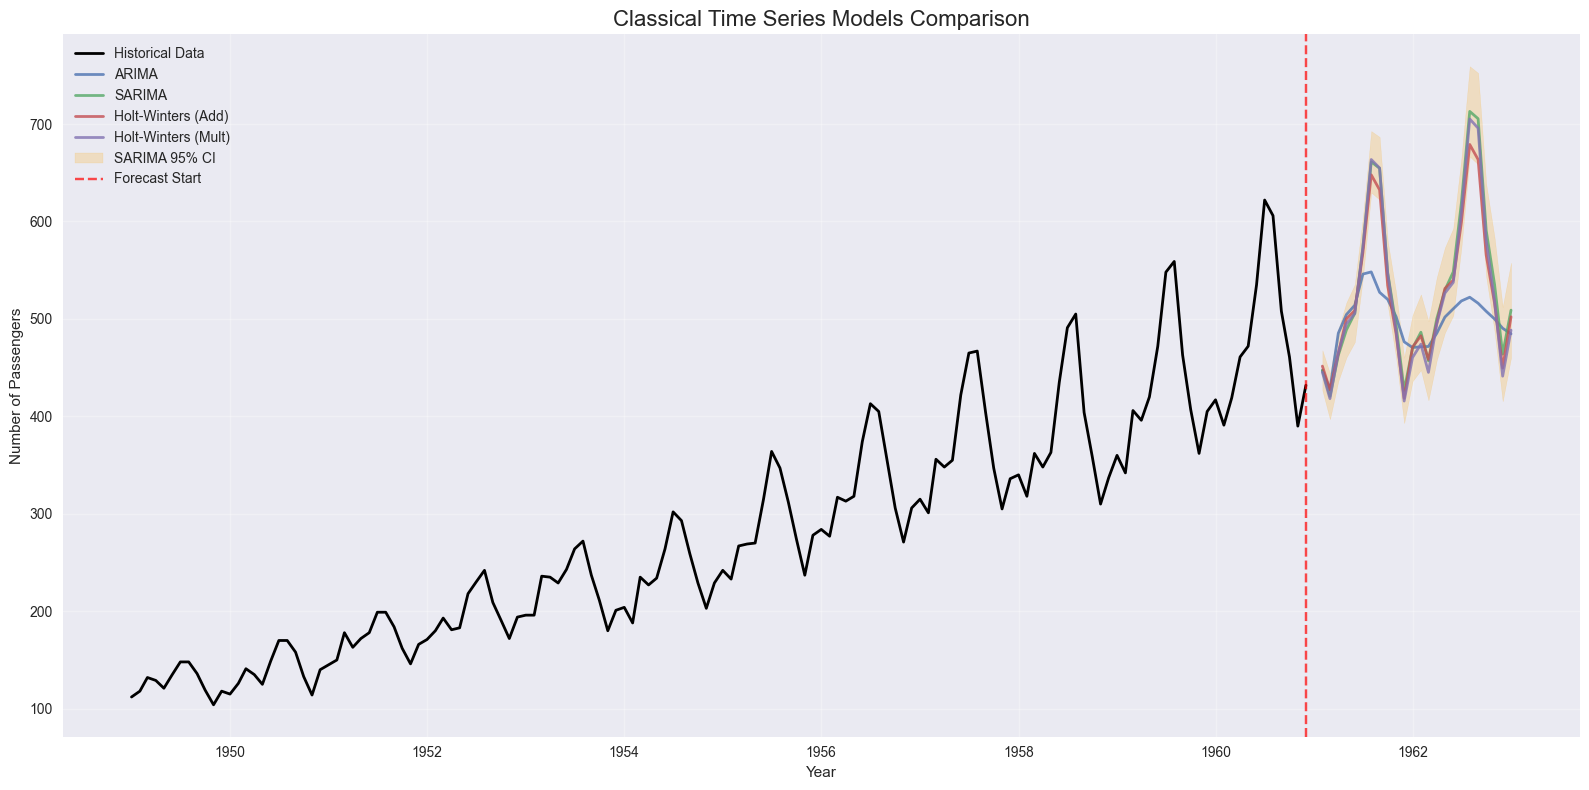

Model Comparison (AIC):
ARIMA: 1335.12
SARIMA: 1012.09
Holt-Winters (Add): 753.29
Holt-Winters (Mult): 709.89


In [87]:
# Compare all classical models
fig, ax = plt.subplots(figsize=(16, 8))

# Plot historical data
ax.plot(df.index, df['Passengers'], label='Historical Data', linewidth=2, color='black')

# Plot forecasts
ax.plot(forecast_dates, arima_forecast, label='ARIMA', linewidth=2, alpha=0.8)
ax.plot(forecast_dates, sarima_forecast, label='SARIMA', linewidth=2, alpha=0.8)
ax.plot(forecast_dates, hw_add_forecast, label='Holt-Winters (Add)', linewidth=2, alpha=0.8)
ax.plot(forecast_dates, hw_mult_forecast, label='Holt-Winters (Mult)', linewidth=2, alpha=0.8)

# Add confidence intervals for SARIMA
ax.fill_between(forecast_dates, 
                sarima_conf_int.iloc[:, 0], 
                sarima_conf_int.iloc[:, 1], 
                alpha=0.2, color='orange', label='SARIMA 95% CI')

ax.axvline(x=df.index[-1], color='red', linestyle='--', alpha=0.7, label='Forecast Start')
ax.set_title('Classical Time Series Models Comparison', fontsize=16)
ax.set_ylabel('Number of Passengers')
ax.set_xlabel('Year')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate AIC for comparison
print("Model Comparison (AIC):")
print(f"ARIMA: {arima_fitted.aic:.2f}")
print(f"SARIMA: {sarima_fitted.aic:.2f}")
print(f"Holt-Winters (Add): {hw_add_fitted.aic:.2f}")
print(f"Holt-Winters (Mult): {hw_mult_fitted.aic:.2f}")

## Part 2: Machine Learning Approaches (60 minutes)

### 2.1 Feature Engineering for Time Series

Converting time series into tabular format for ML algorithms is crucial.

In [88]:
def create_time_features(data):
    """
    Create comprehensive time-based features
    """
    df_features = data.copy()
    
    # Temporal features
    df_features['year'] = df_features.index.year
    df_features['month'] = df_features.index.month
    df_features['quarter'] = df_features.index.quarter
    df_features['day_of_year'] = df_features.index.dayofyear
    
    # Cyclical features (important for capturing seasonality)
    df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
    df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)
    
    return df_features

def create_lag_features(data, target_col, max_lag=12):
    """
    Create lagged features
    """
    df_lag = data.copy()
    
    # Lag features
    for lag in range(1, max_lag + 1):
        df_lag[f'lag_{lag}'] = df_lag[target_col].shift(lag)
    
    return df_lag

def create_rolling_features(data, target_col, windows=[3, 6, 12]):
    """
    Create rolling statistics features
    """
    df_rolling = data.copy()
    
    for window in windows:
        # Rolling mean
        df_rolling[f'rolling_mean_{window}'] = df_rolling[target_col].rolling(window=window).mean()
        
        # Rolling std
        df_rolling[f'rolling_std_{window}'] = df_rolling[target_col].rolling(window=window).std()
        
        # Rolling min/max
        df_rolling[f'rolling_min_{window}'] = df_rolling[target_col].rolling(window=window).min()
        df_rolling[f'rolling_max_{window}'] = df_rolling[target_col].rolling(window=window).max()
    
    return df_rolling

def create_diff_features(data, target_col, lags=[1, 12]):
    """
    Create differencing features
    """
    df_diff = data.copy()
    
    for lag in lags:
        df_diff[f'diff_{lag}'] = df_diff[target_col].diff(lag)
    
    return df_diff


In [89]:
# Apply feature engineering
print("Creating features...")
df_ml = create_time_features(df)
df_ml = create_lag_features(df_ml, 'Passengers', max_lag=12)
df_ml = create_rolling_features(df_ml, 'Passengers', windows=[3, 6, 12])
df_ml = create_diff_features(df_ml, 'Passengers', lags=[1, 12])

print(f"Original features: {df.shape[1]}")
print(f"After feature engineering: {df_ml.shape[1]}")
print("\nNew features created:")
new_features = [col for col in df_ml.columns if col not in df.columns]
print(new_features)

Creating features...
Original features: 5
After feature engineering: 37

New features created:
['year', 'month', 'quarter', 'day_of_year', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_min_3', 'rolling_max_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_min_6', 'rolling_max_6', 'rolling_mean_12', 'rolling_std_12', 'rolling_min_12', 'rolling_max_12', 'diff_1', 'diff_12']


### 2.2 Time Series Cross-Validation

**Critical**: Standard k-fold CV violates temporal order. We need time-aware validation.

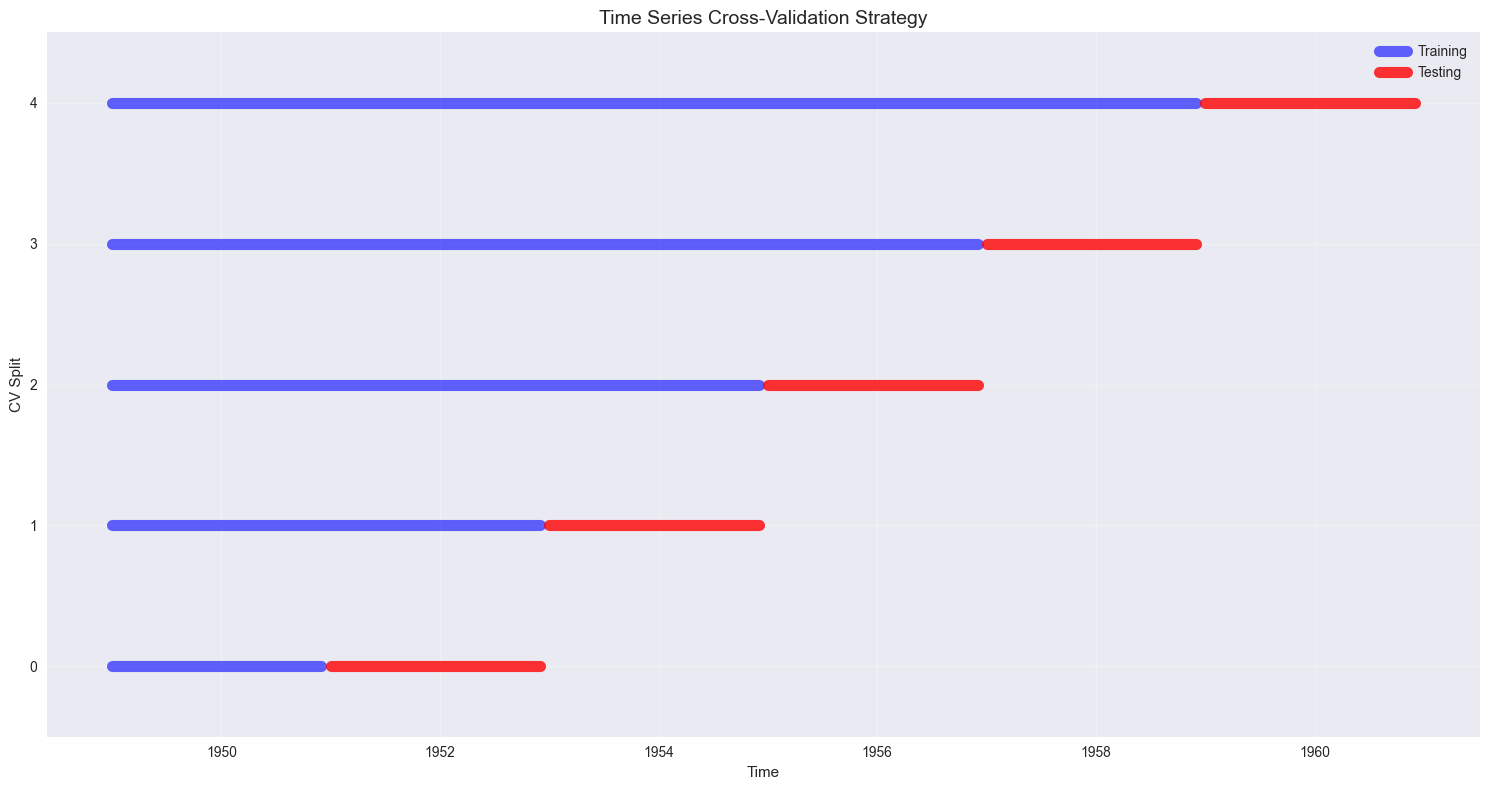

In [90]:
def plot_time_series_cv(data, n_splits=5):
    """
    Visualize time series cross-validation splits
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    fig, ax = plt.subplots(figsize=(15, 8))
    
    for i, (train_idx, test_idx) in enumerate(tscv.split(data)):
        # Plot training data
        ax.plot(data.index[train_idx], [i] * len(train_idx), 
                'b-', alpha=0.6, linewidth=8, label='Training' if i == 0 else "")
        
        # Plot test data
        ax.plot(data.index[test_idx], [i] * len(test_idx), 
                'r-', alpha=0.8, linewidth=8, label='Testing' if i == 0 else "")
    
    ax.set_ylim(-0.5, n_splits - 0.5)
    ax.set_ylabel('CV Split')
    ax.set_xlabel('Time')
    ax.set_title('Time Series Cross-Validation Strategy', fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize CV strategy
plot_time_series_cv(df_ml, n_splits=5)

## 2.3 XGBoost Model with Time Series CV

In [91]:
# Prepare data for ML
def prepare_ml_data(data, target_col='Passengers', test_size=24):
    """
    Prepare data for machine learning
    """
    # Remove rows with NaN values (due to lagging and rolling features)
    data_clean = data.dropna()
    
    # Define features (exclude target and non-predictive columns)
    exclude_cols = [target_col, 'Log_Passengers', 'Passengers_diff1', 
                   'Passengers_seasonal_diff', 'Passengers_diff1_seasonal']
    feature_cols = [col for col in data_clean.columns if col not in exclude_cols]
    
    # Split data
    X = data_clean[feature_cols]
    y = data_clean[target_col]
    
    # Time series split (last test_size observations for testing)
    X_train, X_test = X[:-test_size], X[-test_size:]
    y_train, y_test = y[:-test_size], y[-test_size:]
    
    return X_train, X_test, y_train, y_test, feature_cols

# Prepare data
X_train, X_test, y_train, y_test, feature_cols = prepare_ml_data(df_ml)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {len(feature_cols)}")

Training set shape: (107, 32)
Test set shape: (24, 32)
Number of features: 32


In [92]:
# XGBoost with Time Series Cross-Validation
def xgb_time_series_cv(X, y, n_splits=5, n_trials=50):
    """
    XGBoost hyperparameter tuning with time series cross-validation
    """
    from sklearn.model_selection import ParameterGrid
    
    # Define parameter grid
    param_grid = {
        'n_estimators': [100, 200, 300], ## number trees
        'max_depth': [3, 5, 7], ## how I prune the tree
        'learning_rate': [0.01, 0.1, 0.2], ## l.rate according to the Boosting algo (check notebook)
        'subsample': [0.8, 0.9, 1.0], ## bootstrapping the dataset according to the proportions  of the list
        'colsample_bytree': [0.8, 0.9, 1.0] ## colsample_bytree is the subsample ratio of columns when constructing each tree.
    }
    
    # Generate random parameter combinations
    np.random.seed(42)
    all_params = list(ParameterGrid(param_grid))
    selected_params = np.random.choice(len(all_params), 
                                       size=min(n_trials, len(all_params)), 
                                       replace=False)
    
    best_score = float('inf')
    best_params = None
    cv_results = []
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    print(f"Running {len(selected_params)} parameter combinations...")
    
    for i, param_idx in enumerate(selected_params):
        params = all_params[param_idx]
        scores = []
        
        # Time series cross-validation
        for train_idx, val_idx in tscv.split(X):
            X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
            y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
            
            # Train model
            model = xgb.XGBRegressor(**params, random_state=42)
            model.fit(X_train_cv, y_train_cv)
            
            # Predict and score
            y_pred = model.predict(X_val_cv)
            score = mean_absolute_error(y_val_cv, y_pred)
            scores.append(score)
        
        # Average score across folds
        avg_score = np.mean(scores)
        cv_results.append((params, avg_score, np.std(scores)))
        
        if avg_score < best_score:
            best_score = avg_score
            best_params = params
        
        if (i + 1) % 10 == 0:
            print(f"Completed {i + 1}/{len(selected_params)} combinations. Best MAE: {best_score:.2f}")
    
    return best_params, best_score, cv_results

# Run hyperparameter tuning
print("Starting hyperparameter tuning with Time Series CV...")
best_xgb_params, best_cv_score, cv_results = xgb_time_series_cv(X_train, y_train)

print(f"\nBest parameters: {best_xgb_params}")
print(f"Best CV MAE: {best_cv_score:.2f}")

Starting hyperparameter tuning with Time Series CV...
Running 50 parameter combinations...
Completed 10/50 combinations. Best MAE: 19.71
Completed 20/50 combinations. Best MAE: 19.32
Completed 30/50 combinations. Best MAE: 19.32
Completed 40/50 combinations. Best MAE: 19.32
Completed 50/50 combinations. Best MAE: 19.32

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best CV MAE: 19.32


In [93]:
## Train final XGBoost model
final_xgb_model = xgb.XGBRegressor(**best_xgb_params, random_state=42)
final_xgb_model.fit(X_train, y_train)

# Make predictions
xgb_train_pred = final_xgb_model.predict(X_train)
xgb_test_pred = final_xgb_model.predict(X_test)

# Calculate metrics
train_mae = mean_absolute_error(y_train, xgb_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
test_mae = mean_absolute_error(y_test, xgb_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))

print("XGBoost Model Performance:")
print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

XGBoost Model Performance:
Training MAE: 0.23
Training RMSE: 0.50
Test MAE: 32.65
Test RMSE: 46.07


### 2.4 Feature Importance Analysis


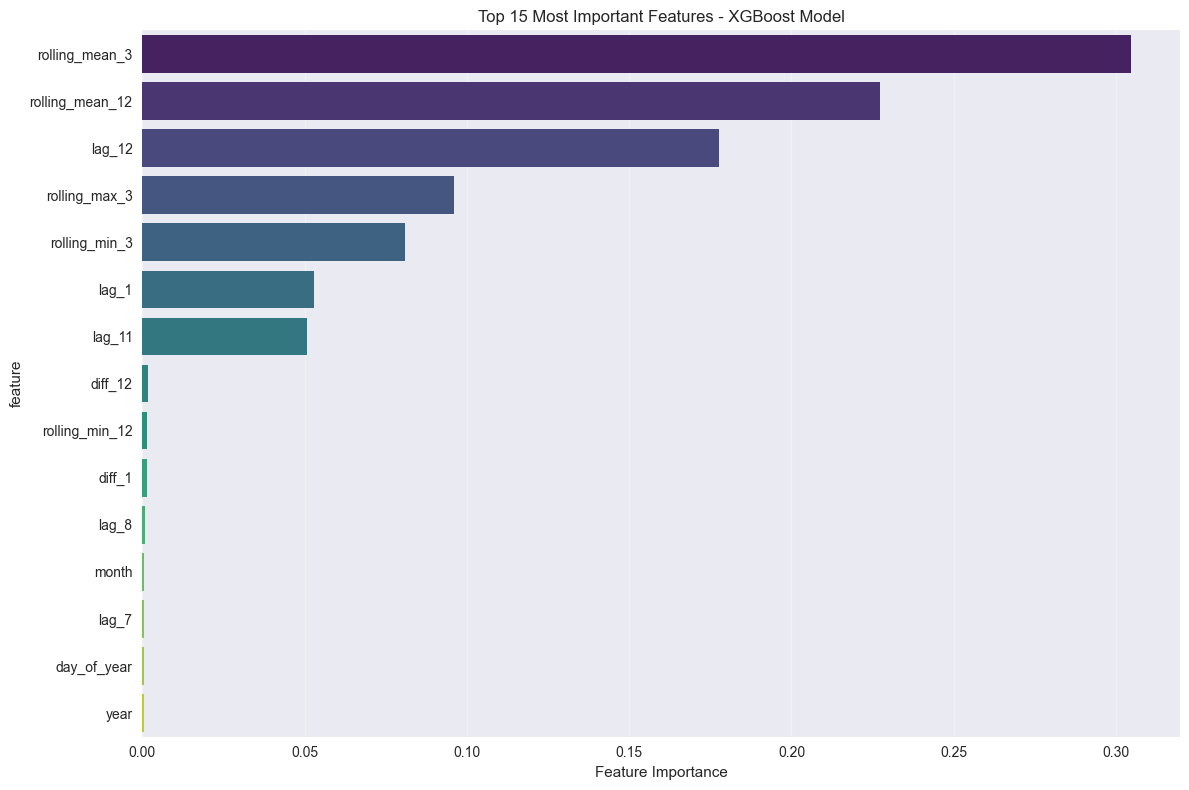

Top 10 Most Important Features:
            feature  importance
18   rolling_mean_3    0.304488
26  rolling_mean_12    0.227254
17           lag_12    0.177799
21    rolling_max_3    0.096125
20    rolling_min_3    0.080951
6             lag_1    0.052813
16           lag_11    0.050811
31          diff_12    0.001656
28   rolling_min_12    0.001540
30           diff_1    0.001303


In [94]:
# Feature importance analysis
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 most important features
plt.figure(figsize=(12, 8))
top_15_features = importance_df.head(15)
sns.barplot(data=top_15_features, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features - XGBoost Model')
plt.xlabel('Feature Importance')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(importance_df.head(10))

### 2.5 Model Comparison: Classical vs ML


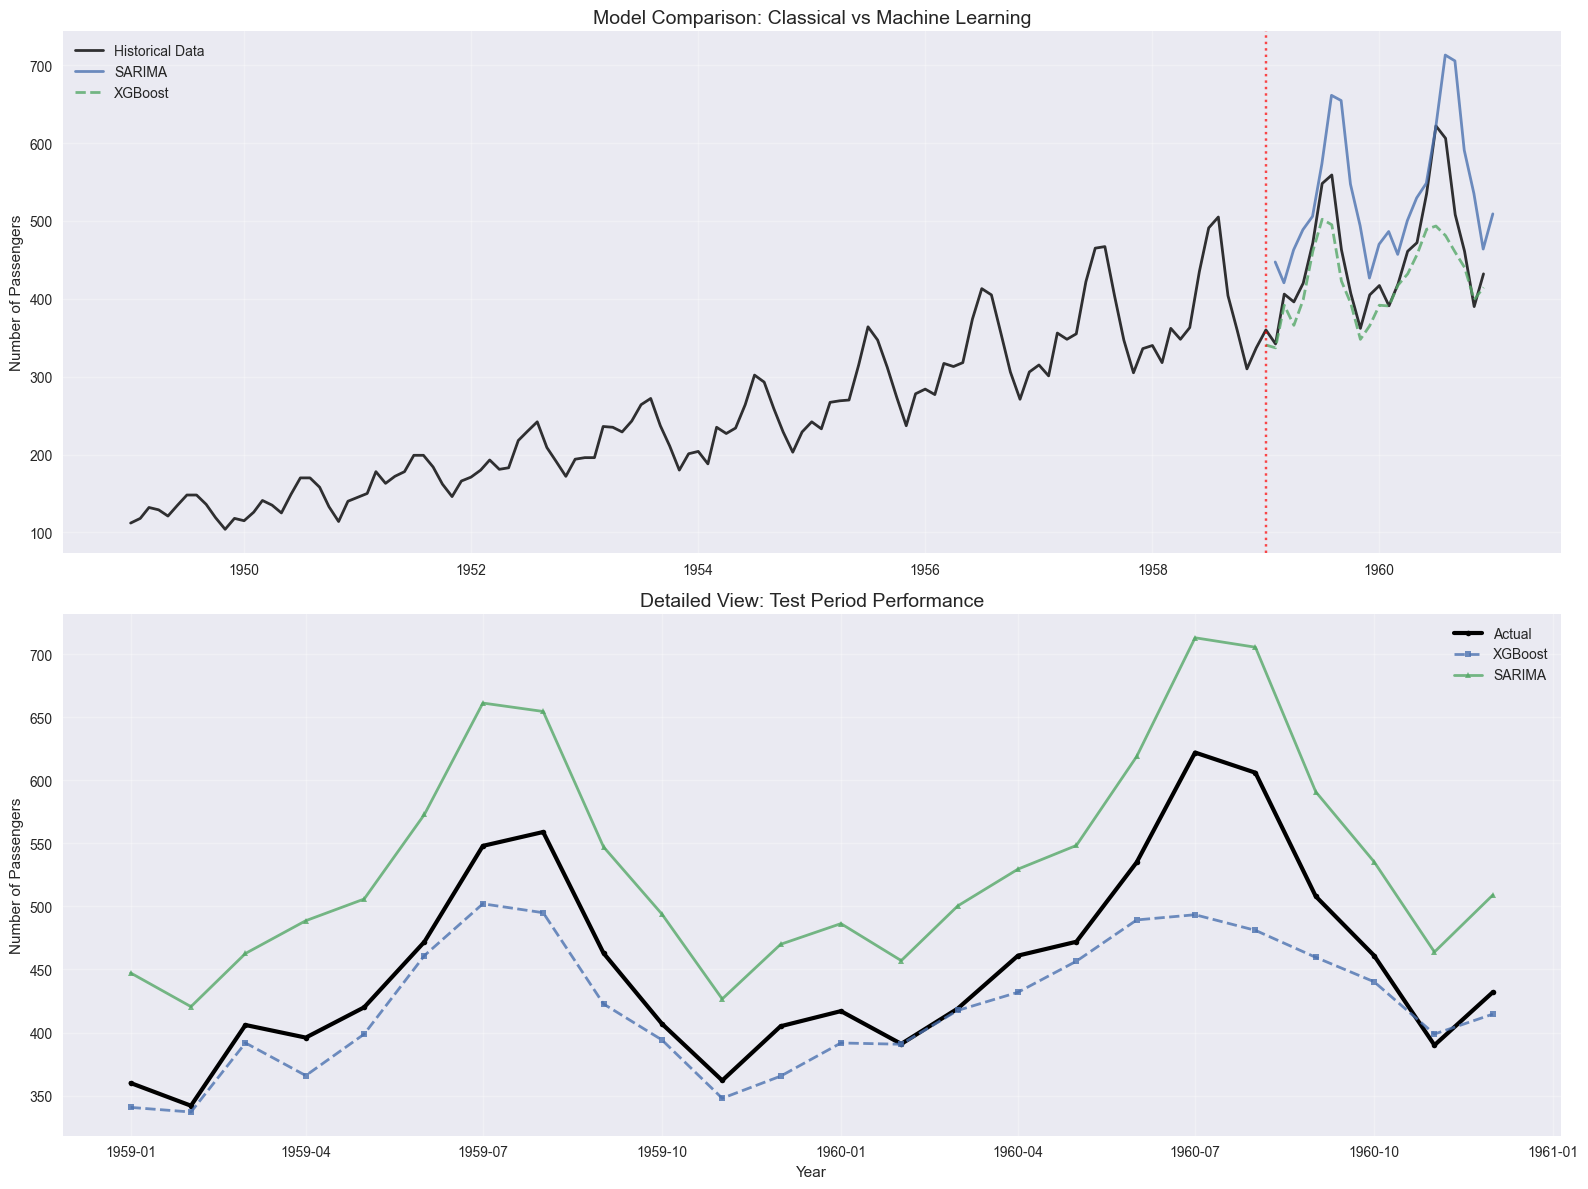

=== MODEL COMPARISON SUMMARY ===
SARIMA Test MAE: 81.49
XGBoost Test MAE: 32.65
SARIMA Test RMSE: 82.54
XGBoost Test RMSE: 46.07


In [95]:
# Create comprehensive comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Full time series with predictions
axes[0].plot(df.index, df['Passengers'], label='Historical Data', 
            linewidth=2, color='black', alpha=0.8)

# Add classical model forecasts (extend dates for visualization)
forecast_dates_extended = pd.date_range(start=df.index[-24], periods=24, freq='M')
axes[0].plot(forecast_dates_extended, sarima_forecast, 
            label='SARIMA', linewidth=2, alpha=0.8)

# Add XGBoost predictions on test set
test_dates = df.index[-24:]
axes[0].plot(test_dates, xgb_test_pred, 
            label='XGBoost', linewidth=2, alpha=0.8, linestyle='--')

axes[0].axvline(x=df.index[-24], color='red', linestyle=':', alpha=0.7)
axes[0].set_title('Model Comparison: Classical vs Machine Learning', fontsize=14)
axes[0].set_ylabel('Number of Passengers')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Focus on test period
axes[1].plot(test_dates, y_test, label='Actual', 
            linewidth=3, color='black', marker='o', markersize=4)
axes[1].plot(test_dates, xgb_test_pred, 
            label='XGBoost', linewidth=2, alpha=0.8, 
            linestyle='--', marker='s', markersize=4)

# Add SARIMA forecast for comparison (first 24 points)
axes[1].plot(test_dates, sarima_forecast[:24], 
            label='SARIMA', linewidth=2, alpha=0.8, marker='^', markersize=4)

axes[1].set_title('Detailed View: Test Period Performance', fontsize=14)
axes[1].set_ylabel('Number of Passengers')
axes[1].set_xlabel('Year')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance metrics comparison
print("=== MODEL COMPARISON SUMMARY ===")
print(f"SARIMA Test MAE: {mean_absolute_error(y_test, sarima_forecast[:24]):.2f}")
print(f"XGBoost Test MAE: {test_mae:.2f}")
print(f"SARIMA Test RMSE: {np.sqrt(mean_squared_error(y_test, sarima_forecast[:24])):.2f}")
print(f"XGBoost Test RMSE: {test_rmse:.2f}")

## Time Series: another ML approach


In [96]:
import warnings                                  # `do not disturbe` mode
warnings.filterwarnings('ignore')

import numpy as np                               # vectors and matrices
import pandas as pd                              # tables and data manipulations
import matplotlib.pyplot as plt                  # plots
import seaborn as sns                            # more plots

from dateutil.relativedelta import relativedelta # working with dates with style
from scipy.optimize import minimize              # for function minimization

import statsmodels.formula.api as smf            # statistics and econometrics
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs

from itertools import product                    # some useful functions
from tqdm import tqdm_notebook



%matplotlib inline

As an example, let's look at real mobile game data. Specifically, we will look into ads watched per hour and in-game currency spend per day:

In [97]:
# data
ads = pd.read_csv('../../data/ads.csv', index_col=['Time'], parse_dates=['Time'])
currency = pd.read_csv('../../data/currency.csv', index_col=['Time'], parse_dates=['Time'])

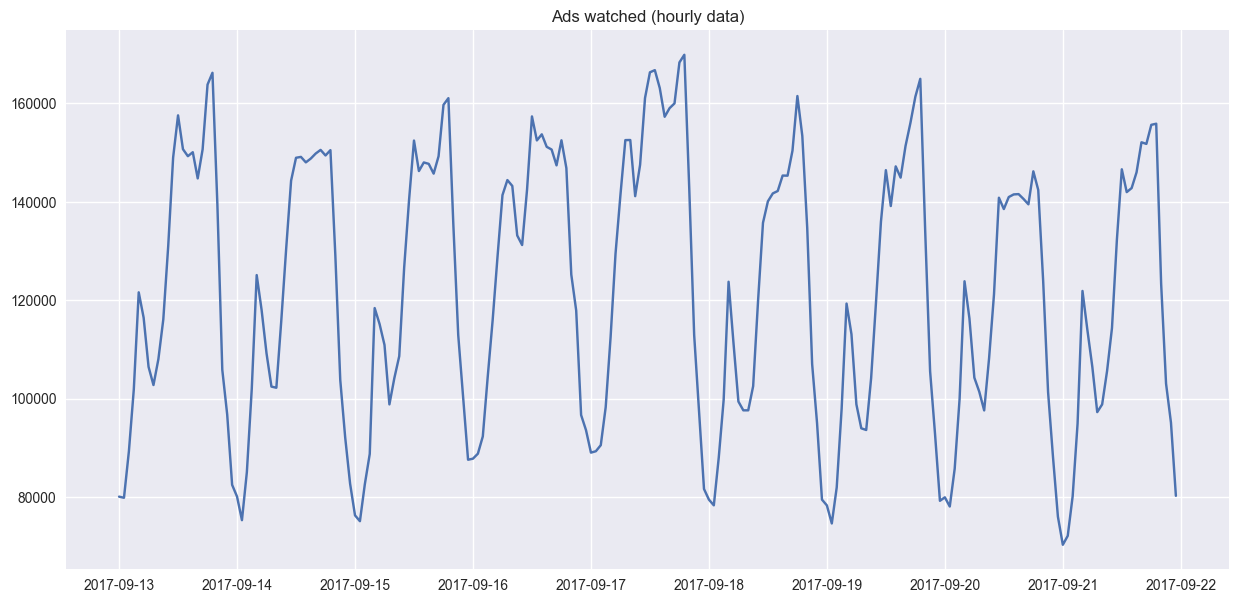

In [98]:
#plot
plt.figure(figsize=(15, 7))
plt.plot(ads.Ads)
plt.title('Ads watched (hourly data)')
plt.grid(True)
plt.show()

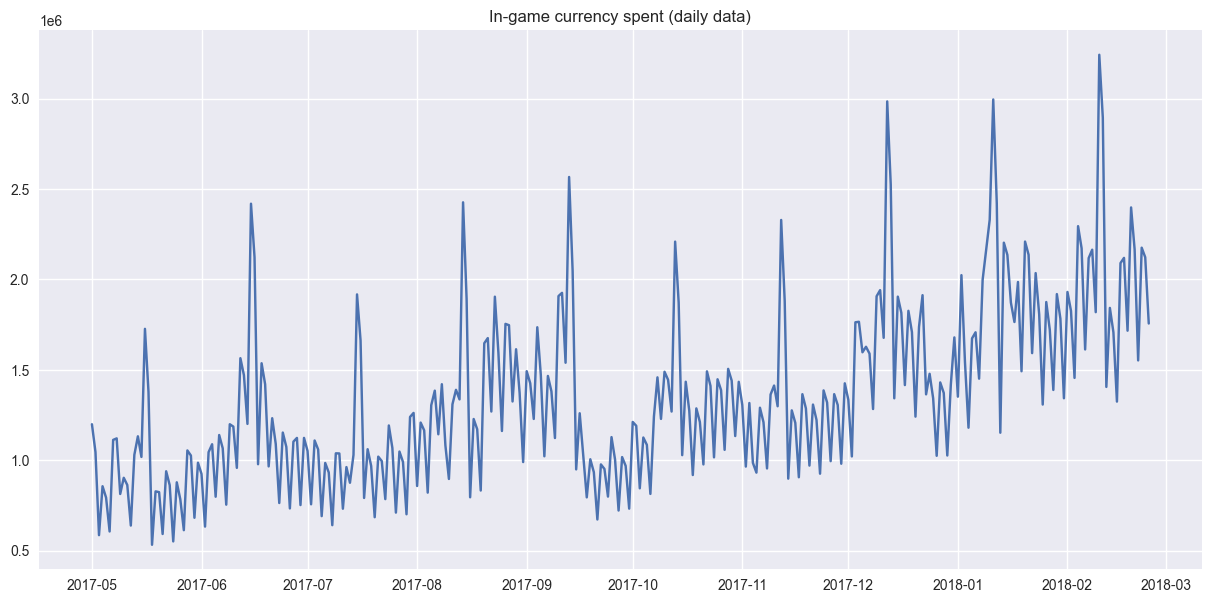

In [99]:
plt.figure(figsize=(15, 7))
plt.plot(currency.GEMS_GEMS_SPENT)
plt.title('In-game currency spent (daily data)')
plt.grid(True)
plt.show()

# Linear (and not quite) models on time series

Often, in my job, I have to build models with [*fast, good, cheap*](http://fastgood.cheap) as my only guiding principle. That means that some of these models will never be considered "production ready" as they demand too much time for data preparation (as in SARIMA) or require frequent re-training on new data (again, SARIMA) or are difficult to tune (good example - SARIMA). Therefore, it's very often much easier to select a few features from the existing time series and build a simple linear regression model or, say, a random forest. It is good and cheap.

This approach is not backed by theory and breaks several assumptions (e.g. Gauss-Markov theorem, especially for errors being uncorrelated), but it is very useful in practice and is often used in machine learning competitions.


# Feature extraction

The model needs features, and all we have is a 1-dimentional time series. What features can we exctract? 
* Lags of time series
* Window statistics:
    - Max/min value of series in a window
    - Average/median value in a window
    - Window variance
    - etc.
* Date and time features:
    - Minute of an hour, hour of a day, day of the week, and so on
    - Is this day a holiday? Maybe there is a special event? Represent that as a boolean feature
* Target encoding 
* Forecasts from other models (note that we can lose the speed of prediction this way)

Let's run through some of the methods and see what we can extract from our ads time series data.

## Lags of time series

Shifting the series $n$ steps back, we get a feature column where the current value of time series is aligned with its value at time $t-n$. If we make a 1 lag shift and train a model on that feature, the model will be able to forecast 1 step ahead from having observed the current state of the series. Increasing the lag, say, up to 6, will allow the model to make predictions 6 steps ahead; however it will use data observed 6 steps back. If something fundamentally changes the series during that unobserved period, the model will not catch these changes and will return forecasts with a large error. Therefore, during the initial lag selection, one has to find a balance between the optimal prediction quality and the length of the forecasting horizon.

In [100]:
# Creating a copy of the initial dataframe to make various transformations 
data = pd.DataFrame(ads.Ads.copy())
data.columns = ["y"]

In [101]:
# Adding the lag of the target variable from 6 steps back up to 24
for i in range(6, 25):
    data["lag_{}".format(i)] = data.y.shift(i)

In [102]:
# take a look at the new dataframe 
data.tail(7)

,y,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
Time,,,,,,,,,,,,,,,,,,,,
2017-09-21 17:00:00,151790,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,113950.0,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0,88170.0,101360.0,123945.0,142425.0,146215.0,139515.0
2017-09-21 18:00:00,155665,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,113950.0,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0,88170.0,101360.0,123945.0,142425.0,146215.0
2017-09-21 19:00:00,155890,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,113950.0,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0,88170.0,101360.0,123945.0,142425.0
2017-09-21 20:00:00,123395,142815.0,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,113950.0,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0,88170.0,101360.0,123945.0
2017-09-21 21:00:00,103080,146020.0,142815.0,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,113950.0,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0,88170.0,101360.0
2017-09-21 22:00:00,95155,152120.0,146020.0,142815.0,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,113950.0,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0,88170.0
2017-09-21 23:00:00,80285,151790.0,152120.0,146020.0,142815.0,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,113950.0,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0


Great, we have generated a dataset here. Why don't we now train a model? 

In [103]:
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# for time-series cross-validation set 5 folds
tscv = TimeSeriesSplit(n_splits=5)

In [104]:
# function train test split

def timeseries_train_test_split(X, y, test_size):
    """
        Perform train-test split with respect to time series structure
    """

    # get the index after which test set starts
    test_index = int(len(X)*(1-test_size))

    X_train = X.iloc[:test_index]
    y_train = y.iloc[:test_index]
    X_test = X.iloc[test_index:]
    y_test = y.iloc[test_index:]

    return X_train, X_test, y_train, y_test


In [105]:
# reserve 30% of data for testing
y = data.dropna().y
X = data.dropna().drop(['y'], axis=1)

# reserve 30% of data for testing
X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

In [106]:
# machine learning in two lines
# machine learning in two lines
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [107]:
def plotModelResults(model, X_train=X_train, X_test=X_test, plot_intervals=False, plot_anomalies=False):
    """
        Plots modelled vs fact values, prediction intervals and anomalies
    
    """
    
    prediction = model.predict(X_test)
    
    plt.figure(figsize=(15, 7))
    plt.plot(prediction, "g", label="prediction", linewidth=2.0)
    plt.plot(y_test.values, label="actual", linewidth=2.0)
    
    if plot_intervals:
        cv = cross_val_score(model, X_train, y_train, 
                                    cv=tscv, 
                                    scoring="neg_mean_absolute_error")
        mae = cv.mean() * (-1)
        deviation = cv.std()
        
        scale = 1.96
        lower = prediction - (mae + scale * deviation)
        upper = prediction + (mae + scale * deviation)
        
        plt.plot(lower, "r--", label="upper bond / lower bond", alpha=0.5)
        plt.plot(upper, "r--", alpha=0.5)
        
        if plot_anomalies:
            anomalies = np.array([np.NaN]*len(y_test))
            anomalies[y_test<lower] = y_test[y_test<lower]
            anomalies[y_test>upper] = y_test[y_test>upper]
            plt.plot(anomalies, "o", markersize=10, label = "Anomalies")
    
    error = mean_absolute_percentage_error(prediction, y_test)
    plt.title("Mean absolute percentage error {0:.2f}%".format(error))
    plt.legend(loc="best")
    plt.tight_layout()
    plt.grid(True);
    
def plotCoefficients(model):
    """
        Plots sorted coefficient values of the model
    """
    
    coefs = pd.DataFrame(model.coef_, X_train.columns)
    coefs.columns = ["coef"]
    coefs["abs"] = coefs.coef.apply(np.abs)
    coefs = coefs.sort_values(by="abs", ascending=False).drop(["abs"], axis=1)
    
    plt.figure(figsize=(15, 7))
    coefs.coef.plot(kind='bar')
    plt.grid(True, axis='y')
    plt.hlines(y=0, xmin=0, xmax=len(coefs), linestyles='dashed');

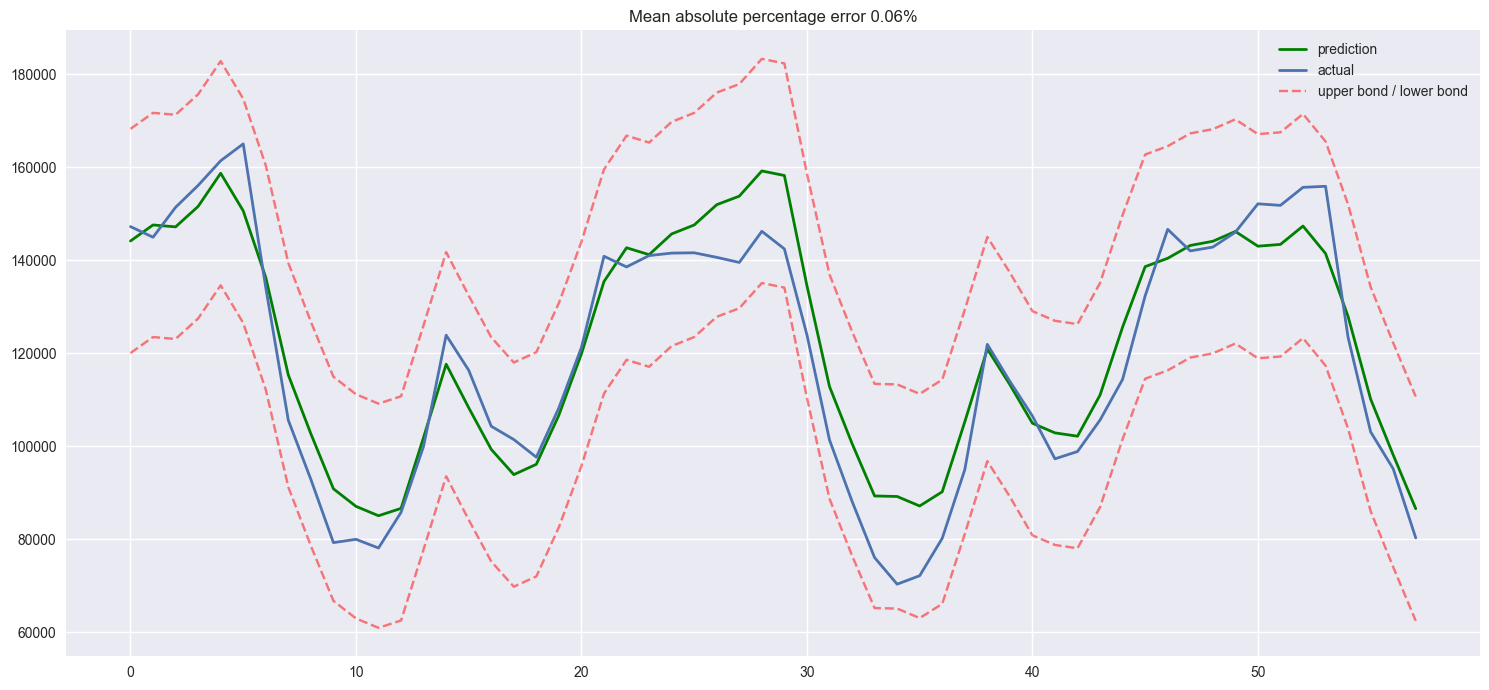

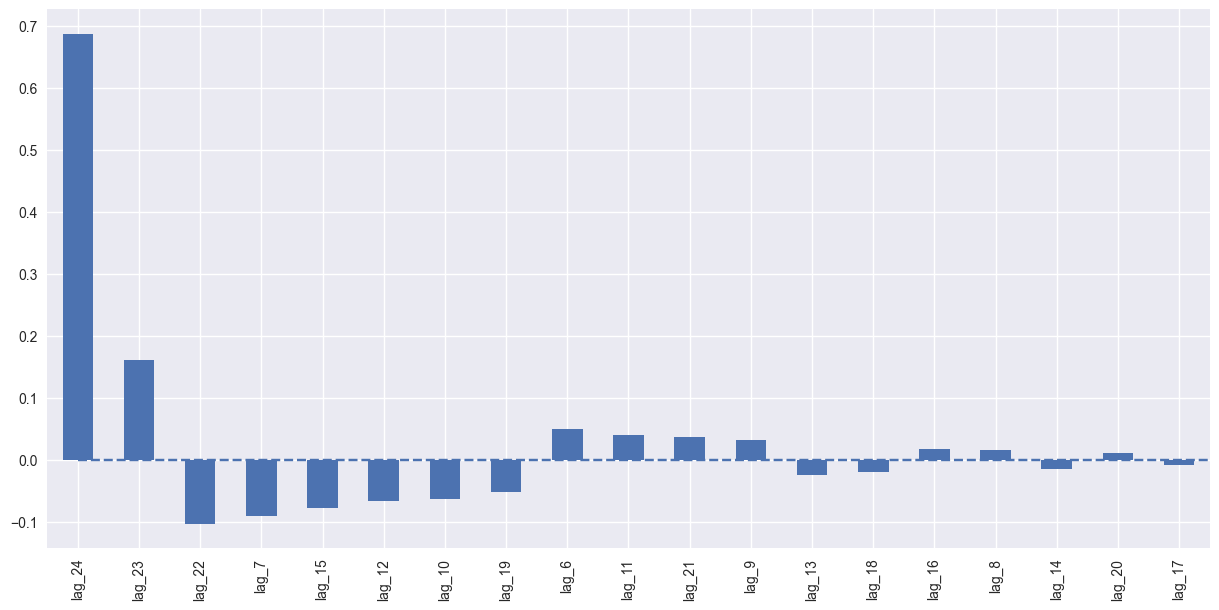

In [108]:
from sklearn.metrics import mean_absolute_percentage_error

#plots


plotModelResults(lr, plot_intervals=True)
plotCoefficients(lr)

Simple lags and linear regression gave us predictions that are not that far off from SARIMA in terms of quality. There are many unnecessary features, so we'll do feature selection in a little while. For now, let's continue engineering!

We'll add hour, day of week, and a boolean for `is_weekend`. To do so, we need to transform the current dataframe index into the `datetime` format and extract `hour` and `weekday`.

In [109]:
# data.index = pd.to_datetime(data.index)
data["hour"] = data.index.hour
data["weekday"] = data.index.weekday
data['is_weekend'] = data.weekday.isin([5,6])*1
data.tail()

,y,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,...,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,hour,weekday,is_weekend
Time,,,,,,,,,,,,,,,,,,,,,
2017-09-21 19:00:00,155890,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,113950.0,...,72150.0,70335.0,76050.0,88170.0,101360.0,123945.0,142425.0,19,3,0
2017-09-21 20:00:00,123395,142815.0,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,106495.0,...,80195.0,72150.0,70335.0,76050.0,88170.0,101360.0,123945.0,20,3,0
2017-09-21 21:00:00,103080,146020.0,142815.0,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,97290.0,...,94945.0,80195.0,72150.0,70335.0,76050.0,88170.0,101360.0,21,3,0
2017-09-21 22:00:00,95155,152120.0,146020.0,142815.0,141995.0,146630.0,132335.0,114380.0,105635.0,98860.0,...,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0,88170.0,22,3,0
2017-09-21 23:00:00,80285,151790.0,152120.0,146020.0,142815.0,141995.0,146630.0,132335.0,114380.0,105635.0,...,113950.0,121910.0,94945.0,80195.0,72150.0,70335.0,76050.0,23,3,0


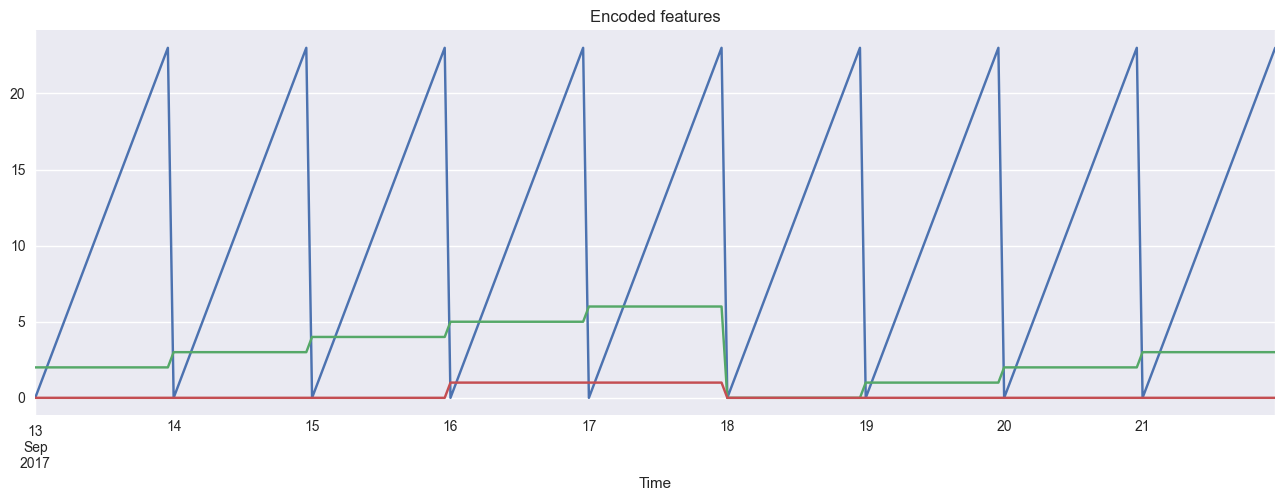

In [110]:
#plot encoded features
plt.figure(figsize=(16, 5))
plt.title("Encoded features")
data.hour.plot()
data.weekday.plot()
data.is_weekend.plot()
plt.grid(True);

Since we now have different scales in our variables, thousands for the lag features and tens for categorical, we need to transform them into same scale for exploring feature importance and, later, regularization. 

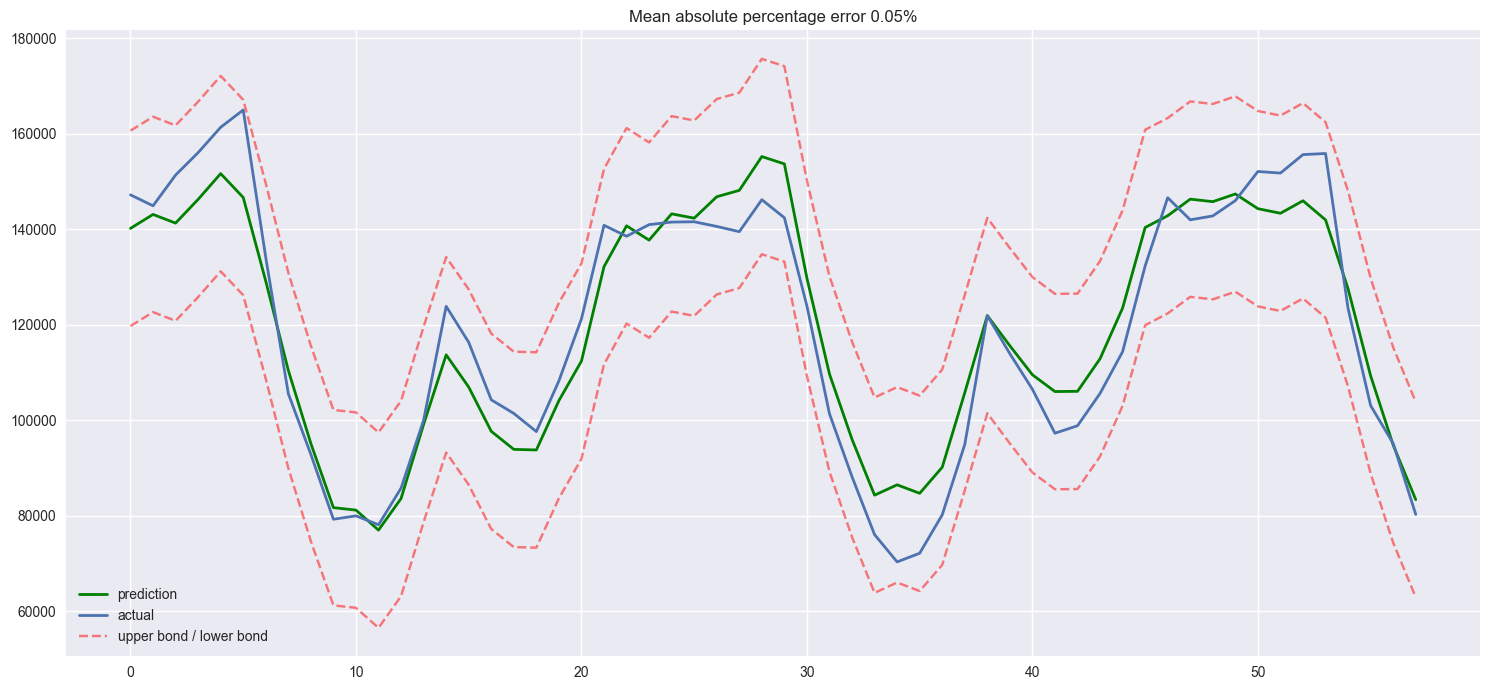

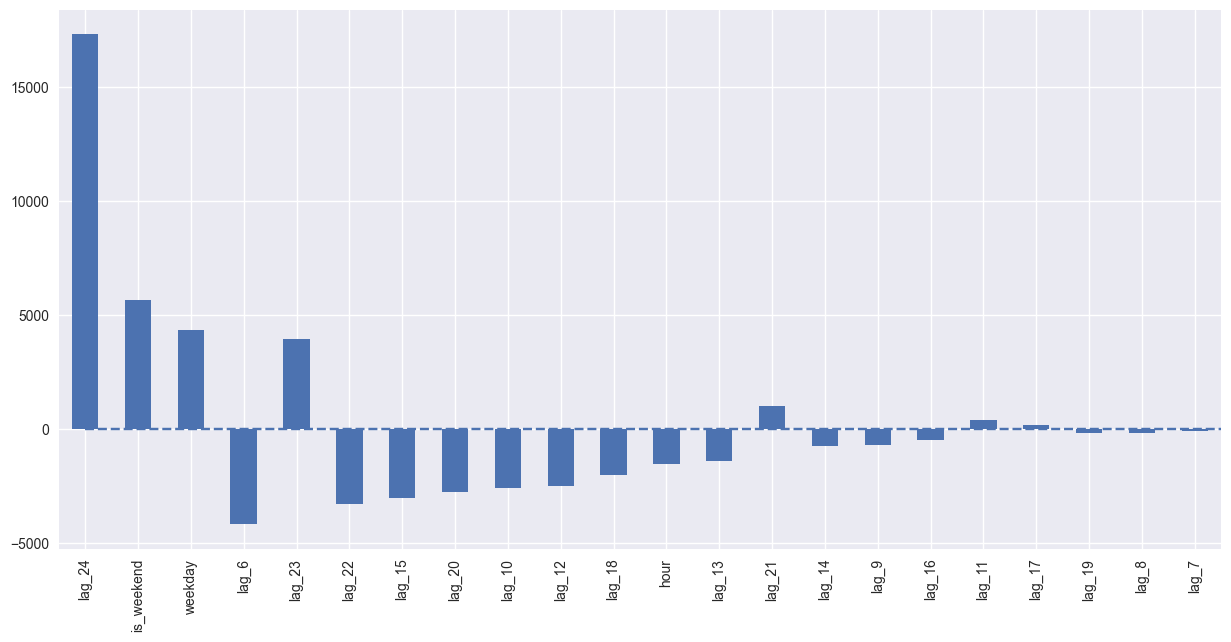

In [111]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

y = data.dropna().y
X = data.dropna().drop(['y'], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

plotModelResults(lr, X_train=X_train_scaled, X_test=X_test_scaled, plot_intervals=True)
plotCoefficients(lr)

The test error goes down a little bit. Judging by the coefficients plot, we can say that `weekday` and `is_weekend` are useful features.

## Target encoding
I'd like to add another variant for encoding categorical variables: encoding by mean value. If it is undesirable to explode a dataset by using many dummy variables that can lead to the loss of information and if they cannot be used as real values because of the conflicts like "0 hours < 23 hours", then it's possible to encode a variable with slightly more interpretable values. The natural idea is to encode with the mean value of the target variable. In our example, every day of the week and every hour of the day can be encoded by the corresponding average number of ads watched during that day or hour. It's very important to make sure that the mean value is calculated over the training set only (or over the current cross-validation fold only) so that the model is not aware of the future.

In [112]:
def code_mean(data, cat_feature, real_feature):
    """
    Returns a dictionary where keys are unique categories of the cat_feature,
    and values are means over real_feature
    """
    return dict(data.groupby(cat_feature)[real_feature].mean())

Let's look at the averages by hour.

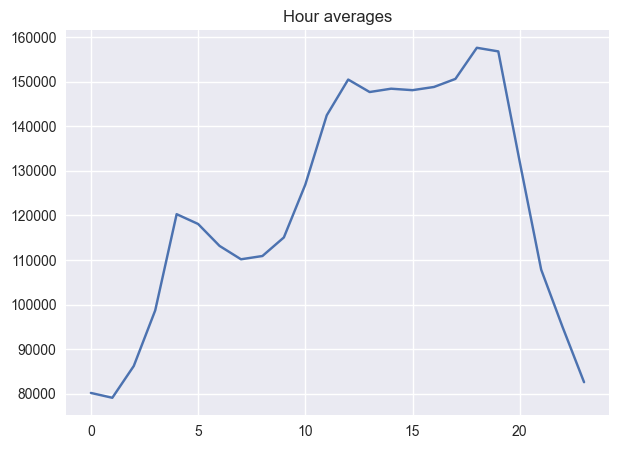

In [113]:
average_hour = code_mean(data, 'hour', "y")
plt.figure(figsize=(7, 5))
plt.title("Hour averages")
pd.DataFrame.from_dict(average_hour, orient='index')[0].plot()
plt.grid(True);

Finally, let's put all the transformations together in a single function .

In [114]:
def prepareData(series, lag_start, lag_end, test_size, target_encoding=False):
    """
        series: pd.DataFrame
            dataframe with timeseries

        lag_start: int
            initial step back in time to slice target variable 
            example - lag_start = 1 means that the model 
                      will see yesterday's values to predict today

        lag_end: int
            final step back in time to slice target variable
            example - lag_end = 4 means that the model 
                      will see up to 4 days back in time to predict today

        test_size: float
            size of the test dataset after train/test split as percentage of dataset

        target_encoding: boolean
            if True - add target averages to the dataset
        
    """
    
    # copy of the initial dataset
    data = pd.DataFrame(series.copy())
    data.columns = ["y"]
    
    # lags of series
    for i in range(lag_start, lag_end):
        data["lag_{}".format(i)] = data.y.shift(i)
    
    # datetime features
    data.index = pd.to_datetime(data.index)
    data["hour"] = data.index.hour
    data["weekday"] = data.index.weekday
    data['is_weekend'] = data.weekday.isin([5,6])*1
    
    if target_encoding:
        # calculate averages on train set only
        test_index = int(len(data.dropna())*(1-test_size))
        data['weekday_average'] = list(map(code_mean(data[:test_index], 'weekday', "y").get, data.weekday))
        data["hour_average"] = list(map(code_mean(data[:test_index], 'hour', "y").get, data.hour))

        # frop encoded variables 
        data.drop(["hour", "weekday"], axis=1, inplace=True)
    
    # train-test split
    y = data.dropna().y
    X = data.dropna().drop(['y'], axis=1)
    X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=test_size)

    return X_train, X_test, y_train, y_test

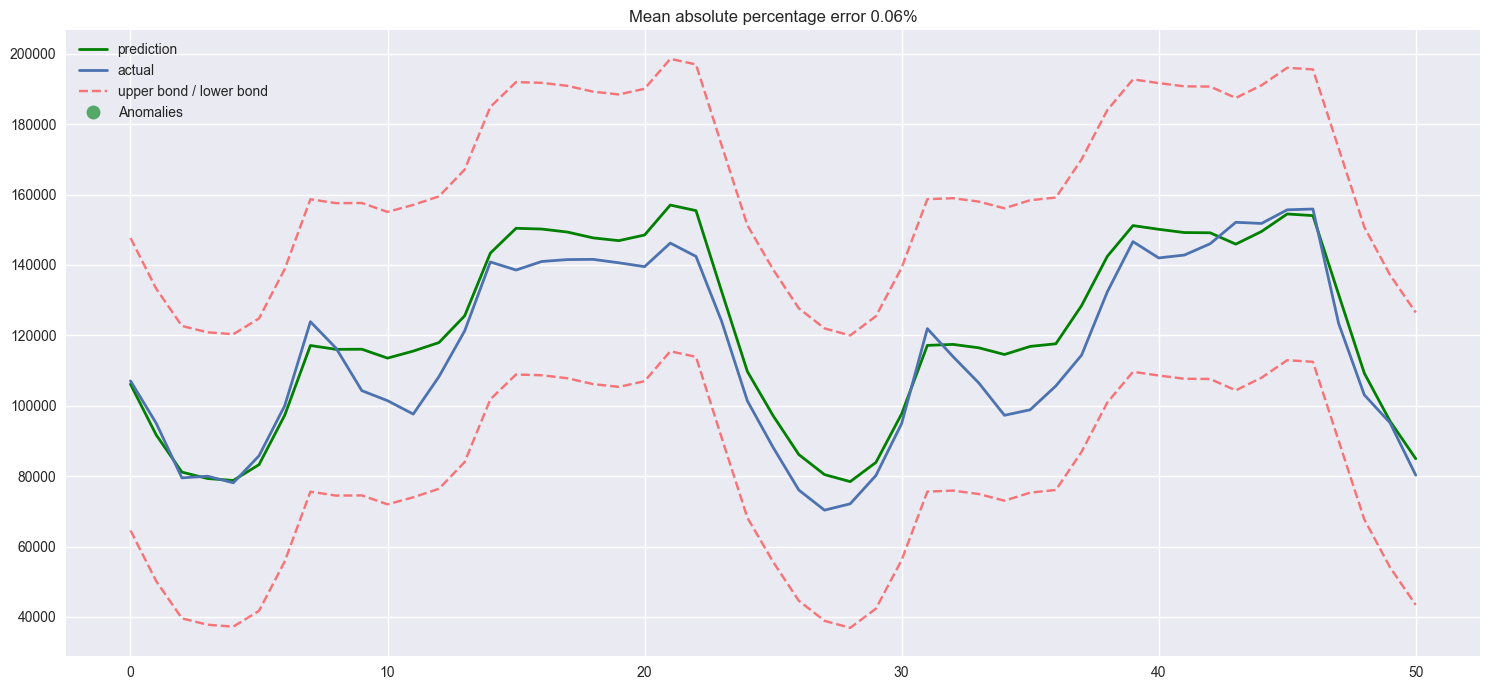

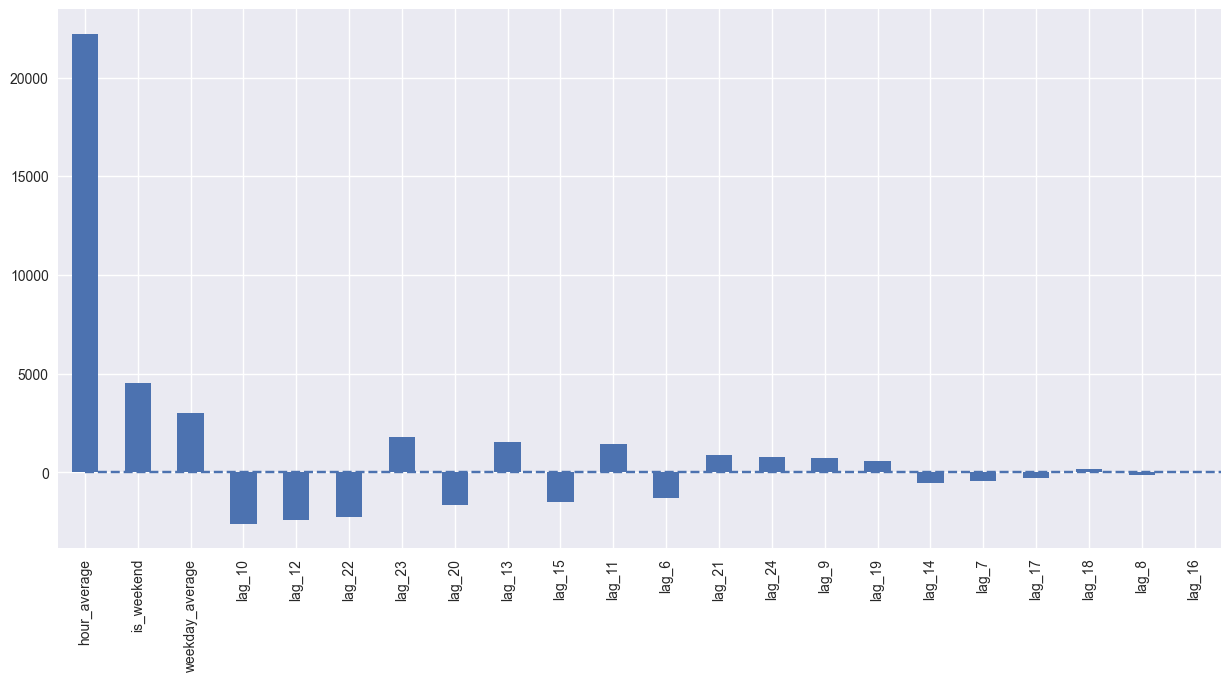

In [115]:
X_train, X_test, y_train, y_test = prepareData(ads.Ads, lag_start=6, lag_end=25, test_size=0.3, target_encoding=True)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

plotModelResults(lr, X_train=X_train_scaled, X_test=X_test_scaled, plot_intervals=True, plot_anomalies=True)
plotCoefficients(lr)

We see some **overfitting**! `Hour_average` was so great in the training dataset that the model decided to concentrate all of its forces on it. As a result, the quality of prediction dropped. This problem can be solved in a variety of ways; for example, we can calculate the target encoding not for the whole train set, but for some window instead. That way, encodings from the last observed window will most likely better describe the current series state. Alternatively, we can just drop it manually since we are sure that it makes things only worse in this case. 

In [ ]:
X_train, X_test, y_train, y_test =\
prepareData(ads.Ads, lag_start=6, lag_end=25, test_size=0.3, target_encoding=False)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Regularization and feature selection 

As we already know, not all features are equally healthy -- some may lead to overfitting while others should be removed. Besides manual inspection, we can apply regularization. Two of the most popular regression models with regularization are Ridge and Lasso regressions. They both add some more constrains to our loss function. 

In the case of Ridge regression, those constraints are the sum of squares of the coefficients multiplied by the regularization coefficient. The bigger the coefficient a feature has, the bigger our loss will be. Hence, we will try to optimize the model while keeping the coefficients fairly low. 

As a result of this $L2$ regularization, we will have higher bias and lower variance, so the model will generalize better (at least that's what we hope will happen).

The second regression model, Lasso regression, adds to the loss function, not squares, but absolute values of the coefficients. As a result, during the optimization process, coefficients of unimportant features may become zeroes, which allows for automated feature selection. This regularization type is called $L1$. 

First, let's make sure that we have features to drop and that the data has highly correlated features.

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr());

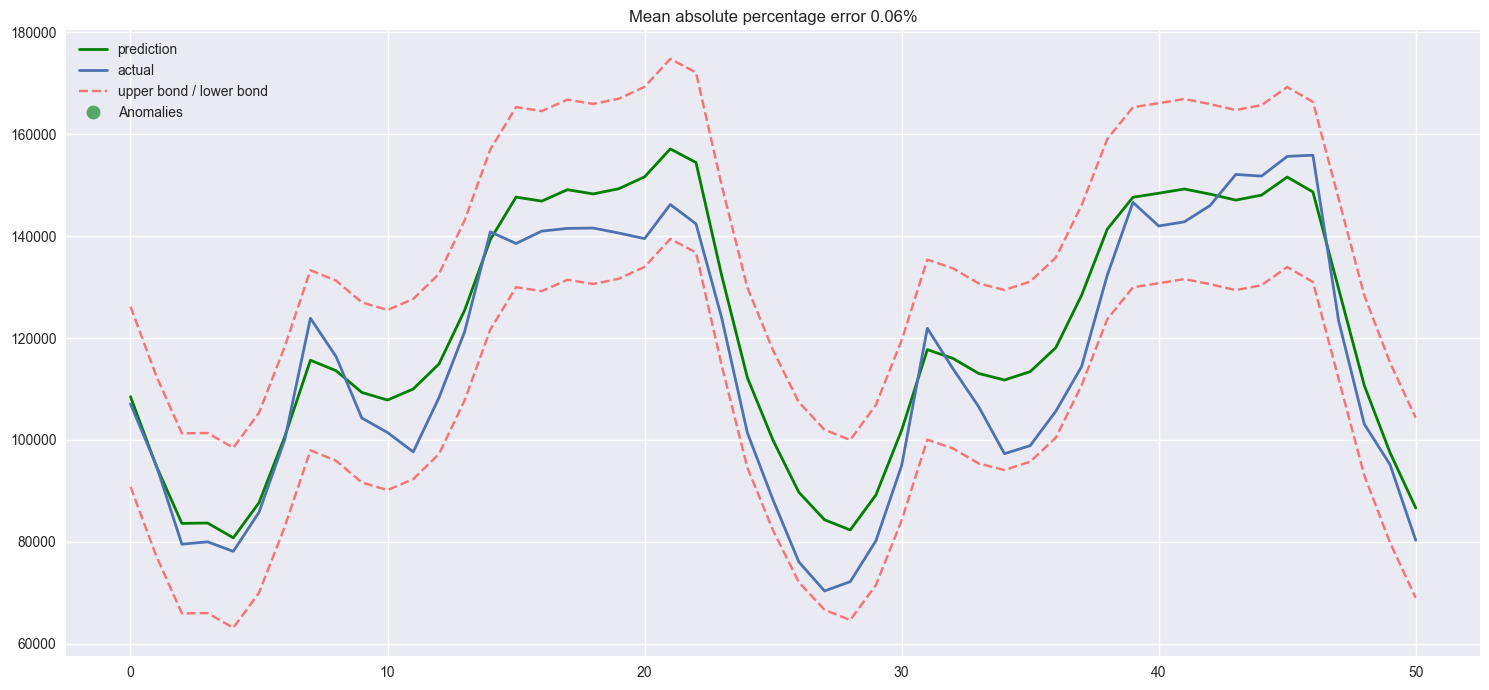

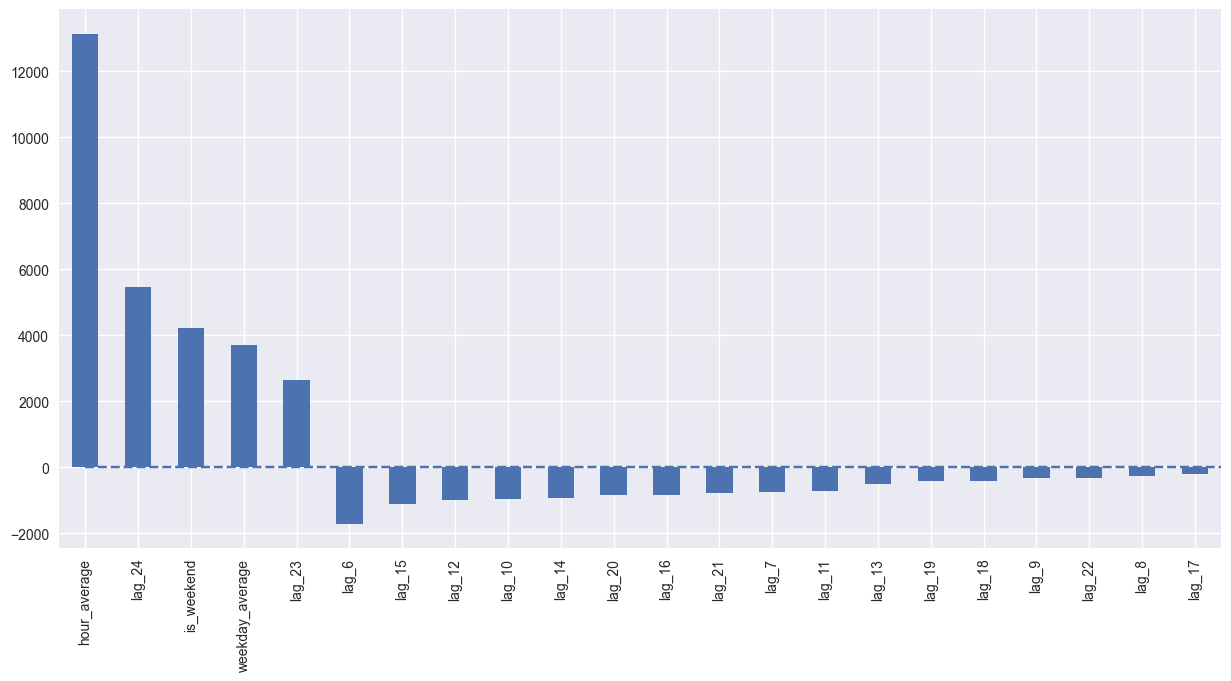

In [116]:
from sklearn.linear_model import LassoCV, RidgeCV

ridge = RidgeCV(cv=tscv)
ridge.fit(X_train_scaled, y_train)

plotModelResults(ridge, 
                 X_train=X_train_scaled, 
                 X_test=X_test_scaled, 
                 plot_intervals=True, plot_anomalies=True)
plotCoefficients(ridge)

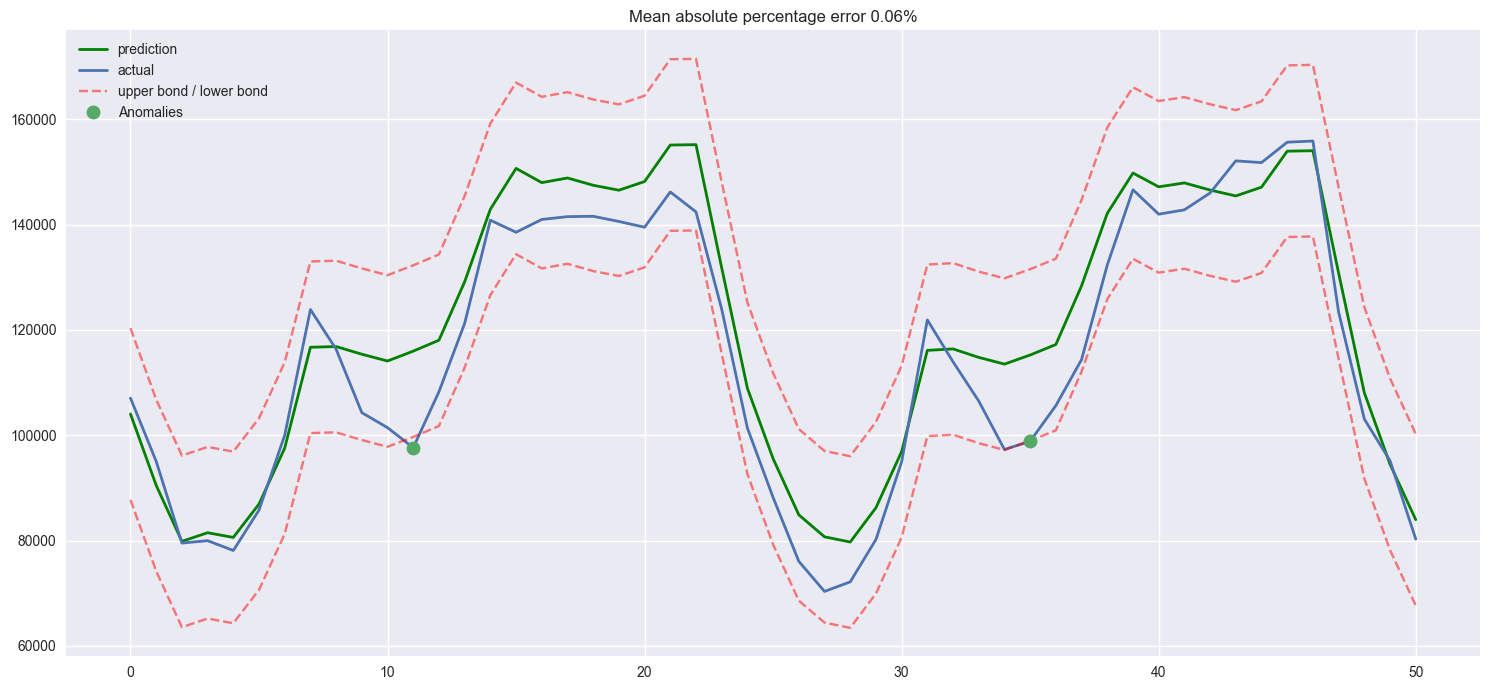

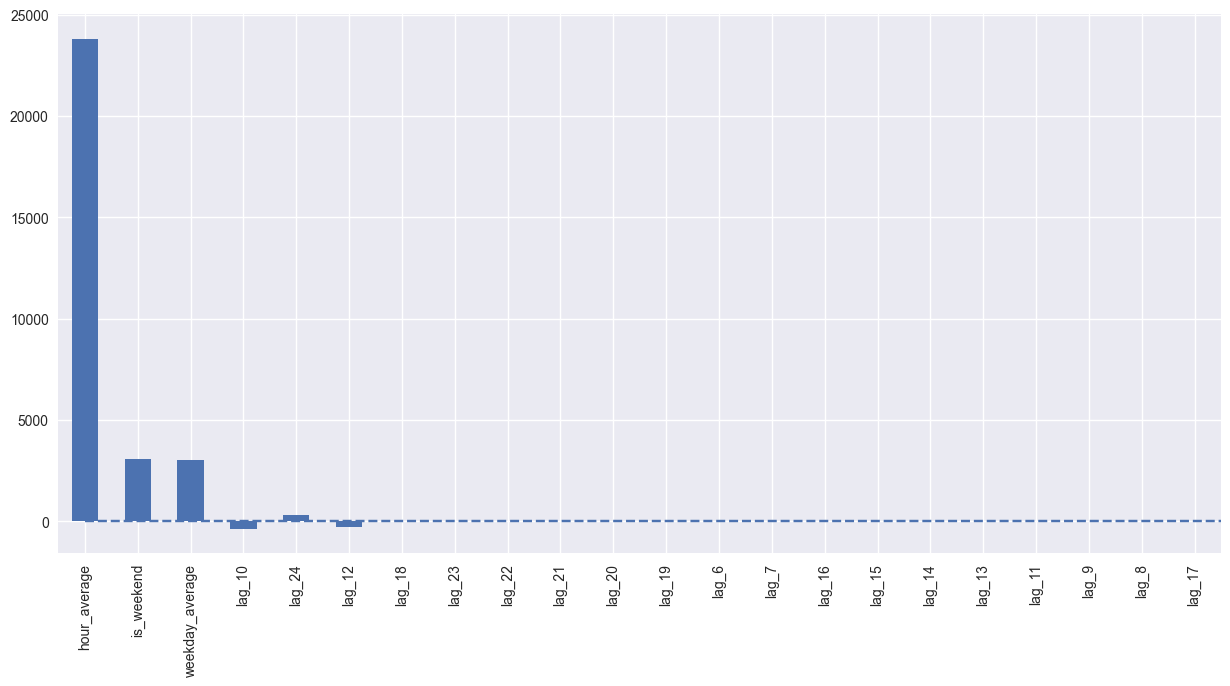

In [118]:
from sklearn.linear_model import LassoCV, RidgeCV

ridge = LassoCV(cv=tscv)
ridge.fit(X_train_scaled, y_train)

plotModelResults(ridge,
                 X_train=X_train_scaled,
                 X_test=X_test_scaled,
                 plot_intervals=True, plot_anomalies=True)
plotCoefficients(ridge)